<a href="https://colab.research.google.com/github/Maverick-Ansh/LatentSpacePEDRL/blob/main/scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LSPE, opened up: Latent State-Predictive Exploration (AAAI-26)

**Paper:** Wang, Zhao, Zhang, Li, U. *Latent State-Predictive Exploration for Deep Reinforcement Learning.* AAAI-26, pp. 26661-26669.

**What this notebook is.** It's a hands-on experiment, not a reproduction. The paper runs on Habitat/HM3D houses, Robosuite arms and a Unitree Go2 robot. None of those fit in a free notebook, and the paper releases no code. So we rebuild **every piece of LSPE from the equations** and run it in a world that keeps the paper's key difficulties:

* a **multi-room house** with a goal in the farthest room (long horizon),
* reward **1 only at the goal** and 0 everywhere else (sparse),
* the agent sees **only pixels**: a 45x45 RGB window around itself (high-dimensional),
* optionally a **noisy TV** that shows fresh random pixels every step (irrelevant noise).

The notebook moves from the smallest pieces to the whole system:

| Part | What you see |
|---|---|
| 1 | The world: maps, what the agent sees, how hard random exploration is |
| 2 | **Why diffusion?** MSE prediction averages two futures into one wrong answer, diffusion keeps both |
| 3 | **The exploration reward** `F = <Δ,z>² · <Σz,z>`: geometry, a numerical check of Theorem 2, and how noisy one direction is |
| 4 | The agent code: encoder φ, diffusion predictor ψ, temporal-aware bisimulation, ERF, PPO, baselines (RND, ICM, NoisyNet), and **the whole architecture as one diagram** with real shapes |
| 5 | Experiments, including **four ways the naive build silently failed** (the encoder collapse is the big one) and the fixes |
| 6 | Results: success, coverage, trajectory heatmaps (the paper's Fig. 2 and Fig. 7) |
| 7 | **Inside LSPE:** the latent map, the "foresight cloud" of predicted futures vs reality, the reward field and how it moves, an episode movie |
| 8 | Ablations (w/o ERF, w MSD, LSPE-E) and the verdict |

The code lives in `%%writefile` cells that build a small package under `/kaggle/working/lspe`. The long training runs execute as detached background jobs, one queue per GPU. Every figure is saved at full resolution to `/kaggle/working/lspe/figs/`. The inline copies are compact JPEG previews.

In [13]:
# ==== SETUP: re-run this cell after any kernel reset ====
import os, sys, io, json, time, math, glob, subprocess, datetime
ROOT = "/kaggle/working/lspe"
for d in ["lspe", "runs", "figs", "logs"]:
    os.makedirs(f"{ROOT}/{d}", exist_ok=True)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
open(f"{ROOT}/lspe/__init__.py", "a").close()

import numpy as np, torch
import matplotlib, matplotlib.pyplot as plt
from PIL import Image as PILImage
from IPython.display import display, Image as IPImage
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 150, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold",
})
DEV = "cuda" if torch.cuda.is_available() else "cpu"

def show(fig, name, max_w=1500, budget_kb=380):
    """Save a full-resolution PNG to figs/, then display a compact JPEG preview inline.
    The inline image is kept under `budget_kb` so a figure can never overflow the notebook relay."""
    fig.savefig(f"{ROOT}/figs/{name}.png", bbox_inches="tight")
    buf = io.BytesIO(); fig.savefig(buf, format="png", dpi=110, bbox_inches="tight"); plt.close(fig)
    im = PILImage.open(buf).convert("RGB")
    if im.width > max_w:
        im = im.resize((max_w, int(im.height * max_w / im.width)), PILImage.LANCZOS)
    for q in (85, 75, 65, 55, 45):
        out = io.BytesIO(); im.save(out, format="JPEG", quality=q, optimize=True)
        if out.tell() < budget_kb * 1024:
            break
        im = im.resize((int(im.width * 0.85), int(im.height * 0.85)), PILImage.LANCZOS)
    display(IPImage(data=out.getvalue(), format="jpeg"))

def purge(pkg="lspe"):
    """Forget cached package modules so edited %%writefile code is re-imported."""
    for m in [k for k in sys.modules if k == pkg or k.startswith(pkg + ".")]:
        del sys.modules[m]

print(datetime.datetime.now(), "| python", sys.version.split()[0], "| torch", torch.__version__)
print(subprocess.run("nvidia-smi --query-gpu=index,name,memory.used,memory.total --format=csv,noheader",
                     shell=True, capture_output=True, text=True).stdout)


2026-09-29 23:52:34.533077 | python 3.12.13 | torch 2.10.0+cu128
0, Tesla T4, 123 MiB, 15360 MiB
1, Tesla T4, 3 MiB, 15360 MiB



## Part 1: The world

The paper's navigation houses (Fig. 4) are named like `1F6R-easy`, meaning 1 floor, 6 rooms, easy. We build four GPU houses in the same spirit:

| level | rooms | doors | episode limit | twist |
|---|---|---|---|---|
| `4R-easy` | 2x2 | tree + 1 extra loop | 150 | none |
| `6R-hard` | 3x2 | a tree: exactly one route between rooms | 250 | none |
| `9R-medium` | 3x3 | tree + 2 extra loops | 350 | none |
| `9R-hard-TV` | 3x3 | tree | 400 | a **noisy TV** in a dead-end room near the start |

**How a house is built.** Rooms sit on a grid. A randomised depth-first search picks which neighbouring rooms share a one-cell door. That is a spanning tree, so there is exactly one route between any two rooms. "Easier" houses get extra doors, which create loops and shortcuts. The goal goes in the room that is farthest from the start room, counted in doors. Every room gets its own floor colour, a per-cell texture and two furniture blocks, so rooms look different in pixels. Furniture is only placed on cells whose four neighbours are all in the same room, so it can never block a door. The builder asserts that every floor cell can reach the goal.

**What the agent sees.** Only a 9x9-cell top-down window centred on itself, rendered at 5 px per cell: a `3x45x45` uint8 image, which is **6075 numbers per state**. On top of that, every frame gets a little Gaussian pixel noise (σ = 3% of full range). The agent never sees its (x, y) position. We keep positions only for the plots.

**Actions:** up, down, left, right (a move into a wall does nothing). **Reward:** 1 on reaching the goal, then the episode ends. Everything else earns 0.

All `n_envs` copies step together as one batch of tensor operations on the GPU, including the rendering, which is a single gather from a pre-drawn map image.

In [14]:
%%writefile /kaggle/working/lspe/lspe/envs.py
"""Multi-room visual navigation, fully batched on the GPU.

A stand-in for the paper's Habitat/HM3D houses: rooms joined by one-cell doors, a goal in the room
farthest from the start, reward 1 only at the goal (sparse), and the agent only sees PIXELS, a 9x9-cell
top-down RGB window around itself (3x45x45 = 6075 numbers). Optional "noisy TV": a block of cells whose
pixels are re-randomised every step. It carries zero task information, which makes it the classic trap
for pixel-novelty bonuses.
"""
from collections import deque
import numpy as np, torch

LEVELS = {
    "4R-easy":    dict(rx=2, ry=2, rs=6, max_steps=150, extra=1, tv=False, seed=11),
    "6R-hard":    dict(rx=3, ry=2, rs=7, max_steps=250, extra=0, tv=False, seed=5),
    "9R-medium":  dict(rx=3, ry=3, rs=6, max_steps=350, extra=2, tv=False, seed=3),
    "9R-hard-TV": dict(rx=3, ry=3, rs=7, max_steps=400, extra=0, tv=True,  seed=7),
}
MOVES = torch.tensor([[0, -1], [0, 1], [-1, 0], [1, 0]])          # up, down, left, right as (dx, dy)
ROOM_COLORS = np.array([[0.93, 0.80, 0.62], [0.68, 0.84, 0.93], [0.74, 0.90, 0.70],
                        [0.95, 0.72, 0.74], [0.82, 0.76, 0.95], [0.96, 0.90, 0.60],
                        [0.66, 0.89, 0.86], [0.92, 0.78, 0.90], [0.80, 0.86, 0.68]])
WALL, DOOR, FURN = np.array([0.18, 0.20, 0.25]), np.array([0.86, 0.86, 0.86]), np.array([0.45, 0.32, 0.22])
GOAL = np.array([1.0, 0.85, 0.0])


def build_layout(rx, ry, rs, extra, tv, seed, **_):
    """Return a dict describing one fixed house (walls, rooms, doors, goal, start room, TV)."""
    rng = np.random.RandomState(seed)
    W, H = rx * (rs + 1) + 1, ry * (rs + 1) + 1
    wall = np.ones((H, W), bool)
    room = -np.ones((H, W), int)                                   # -1 wall, -2 door, k room id
    for j in range(ry):
        for i in range(rx):
            y0, x0 = j * (rs + 1) + 1, i * (rs + 1) + 1
            wall[y0:y0 + rs, x0:x0 + rs] = False
            room[y0:y0 + rs, x0:x0 + rs] = j * rx + i

    def nbrs(k):
        i, j = k % rx, k // rx
        return [(i + a) + (j + b) * rx for a, b in ((1, 0), (-1, 0), (0, 1), (0, -1))
                if 0 <= i + a < rx and 0 <= j + b < ry]

    # randomised DFS spanning tree over rooms => exactly one route between any two rooms
    edges, seen, stack = set(), {0}, [0]
    while stack:
        k = stack[-1]
        opts = [n for n in nbrs(k) if n not in seen]
        if not opts:
            stack.pop(); continue
        n = opts[rng.randint(len(opts))]
        edges.add((min(k, n), max(k, n))); seen.add(n); stack.append(n)
    spare = [(k, n) for k in range(rx * ry) for n in nbrs(k) if k < n and (k, n) not in edges]
    rng.shuffle(spare)
    edges |= set(spare[:extra])                                    # extra doors = loops/shortcuts

    doors = []
    for a, b in sorted(edges):
        ia, ja, ib, jb = a % rx, a // rx, b % rx, b // rx
        off = rng.randint(1, rs + 1)
        if ja == jb:   # side by side -> door in the vertical wall between them
            x, y = max(ia, ib) * (rs + 1), ja * (rs + 1) + off
        else:          # stacked -> door in the horizontal wall
            x, y = ia * (rs + 1) + off, max(ja, jb) * (rs + 1)
        wall[y, x] = False; room[y, x] = -2; doors.append((x, y))

    adj = {k: [] for k in range(rx * ry)}
    for a, b in edges:
        adj[a].append(b); adj[b].append(a)
    rdist, q = {0: 0}, [0]
    for k in q:
        for n in adj[k]:
            if n not in rdist:
                rdist[n] = rdist[k] + 1; q.append(n)
    far = max(rdist.values())
    goal_room = max(k for k in rdist if rdist[k] == far)

    def interior(k):   # cells whose 4 neighbours are all room k: never a wall ring or a door mouth
        ys, xs = np.where(room == k)
        return [(x, y) for x, y in zip(xs, ys)
                if room[y - 1, x] == k and room[y + 1, x] == k and room[y, x - 1] == k and room[y, x + 1] == k]

    tv_room, tv_cells = None, []
    if tv:   # a dead-end room as close to the start as possible (a trap on the way)
        leaves = [k for k in adj if len(adj[k]) == 1 and k not in (0, goal_room)]
        cand = leaves or [k for k in adj if k not in (0, goal_room)]
        tv_room = min(cand, key=lambda k: (rdist[k], k))
        ys, xs = np.where(room == tv_room)
        cx, cy = int(np.round(xs.mean())), int(np.round(ys.mean()))
        tv_cells = [(cx + a, cy + b) for a in (-1, 0, 1) for b in (-1, 0, 1)]

    furn = np.zeros((H, W), bool)
    for k in range(rx * ry):
        cells = [c for c in interior(k) if c not in tv_cells]
        for idx in rng.choice(len(cells), 2, replace=False):
            x, y = cells[idx]; furn[y, x] = True
    wall_or_furn = wall | furn
    gcells = [c for c in interior(goal_room) if not furn[c[1], c[0]]]
    gx, gy = gcells[rng.randint(len(gcells))]
    start_cells = [(x, y) for y, x in zip(*np.where(room == 0)) if not furn[y, x]]
    L = dict(W=W, H=H, rs=rs, rx=rx, ry=ry, wall=wall_or_furn, room=room, furn=furn, doors=doors,
             edges=sorted(edges), goal=(gx, gy), goal_room=goal_room, start_cells=start_cells,
             tv_room=tv_room, tv_cells=tv_cells, room_dist=rdist)
    d = geodesic(L, (gx, gy))
    assert (d[~wall_or_furn] >= 0).all(), "some floor cell cannot reach the goal"
    return L


def geodesic(layout, src):
    """BFS shortest-path distance (in steps) from cell src=(x,y) to every cell; -1 where unreachable."""
    W, H, wall = layout["W"], layout["H"], layout["wall"]
    d = -np.ones((H, W), int); d[src[1], src[0]] = 0; q = deque([src])
    while q:
        x, y = q.popleft()
        for dx, dy in ((0, -1), (0, 1), (-1, 0), (1, 0)):
            nx, ny = x + dx, y + dy
            if 0 <= nx < W and 0 <= ny < H and not wall[ny, nx] and d[ny, nx] < 0:
                d[ny, nx] = d[y, x] + 1; q.append((nx, ny))
    return d


def draw_map(layout, px=5, seed=0):
    """Full top-down RGB image (H*px, W*px, 3) float in [0,1]. TV cells drawn black (noise added live)."""
    rng = np.random.RandomState(1000 + seed)
    H, W, room, furn = layout["H"], layout["W"], layout["room"], layout["furn"]
    img = np.zeros((H, W, 3))
    for y in range(H):
        for x in range(W):
            k = room[y, x]
            img[y, x] = WALL if k == -1 else DOOR if k == -2 else ROOM_COLORS[k % len(ROOM_COLORS)]
            if furn[y, x]:
                img[y, x] = FURN
    img = img * (1 + 0.10 * (rng.rand(H, W, 1) - 0.5))                   # per-cell brightness jitter
    big = np.kron(img, np.ones((px, px, 1)))
    big = big * (1 + 0.10 * (rng.rand(H * px, W * px, 1) - 0.5))         # per-pixel texture
    gx, gy = layout["goal"]
    big[gy * px:(gy + 1) * px, gx * px:(gx + 1) * px] = GOAL
    c = px // 2
    big[gy * px + c, gx * px + c] = [0.8, 0.1, 0.1]
    for (x, y) in layout["tv_cells"]:
        big[y * px:(y + 1) * px, x * px:(x + 1) * px] = 0.0
    return np.clip(big, 0, 1)


class RoomsEnv:
    """n_envs copies of one house, stepped together on `device`. Observations are uint8 (B,3,V,V)."""

    def __init__(self, level, n_envs=128, device="cuda", view=9, px=5, pix_noise=0.03, seed=0):
        cfg = LEVELS[level]
        self.level, self.B, self.dev, self.view, self.px = level, n_envs, device, view, px
        self.r, self.V = view // 2, view * px
        self.pix_noise, self.max_steps = pix_noise, cfg["max_steps"]
        L = self.layout = build_layout(**cfg)
        self.H, self.W = L["H"], L["W"]
        self.wall = torch.tensor(L["wall"], device=device)
        self.gx, self.gy = L["goal"]
        self.start = torch.tensor(L["start_cells"], device=device)            # (S,2) x,y
        fy, fx = np.where(~L["wall"])
        self.floor = torch.tensor(np.stack([fx, fy], 1), device=device)      # every reachable cell
        self.n_floor = len(fx)
        self.map_rgb = draw_map(L, px, seed=cfg["seed"])
        pad = self.r * px
        padded = np.pad(self.map_rgb, ((pad, pad), (pad, pad), (0, 0)), constant_values=0)
        padded[:pad] = WALL; padded[-pad:] = WALL; padded[:, :pad] = WALL; padded[:, -pad:] = WALL
        self.img = torch.tensor((padded * 255).round(), dtype=torch.uint8, device=device)
        tvm = np.zeros((self.H * px, self.W * px), bool)
        for (x, y) in L["tv_cells"]:
            tvm[y * px:(y + 1) * px, x * px:(x + 1) * px] = True
        self.tvmask = torch.tensor(np.pad(tvm, pad), device=device) if L["tv_cells"] else None
        self.ar = torch.arange(self.V, device=device)
        self.moves = MOVES.to(device)
        self.visits = torch.zeros(self.H, self.W, dtype=torch.long, device=device)  # lifetime visit counts
        self.x = torch.zeros(n_envs, dtype=torch.long, device=device)
        self.y = torch.zeros_like(self.x); self.t = torch.zeros_like(self.x)
        self.seen = torch.zeros(n_envs, self.H, self.W, dtype=torch.bool, device=device)
        self.reset_mask(torch.ones(n_envs, dtype=torch.bool, device=device))

    def reset_mask(self, m):
        n = int(m.sum())
        if n == 0:
            return
        s = self.start[torch.randint(len(self.start), (n,), device=self.dev)]
        self.x[m], self.y[m], self.t[m] = s[:, 0], s[:, 1], 0
        self.seen[m] = False
        idx = m.nonzero().squeeze(1)
        self.seen[idx, self.y[idx], self.x[idx]] = True

    def render(self, x=None, y=None, noise=True):
        """Crop the 9x9-cell window around cells (x,y) -> uint8 (B,3,V,V). Agent drawn as a white square."""
        x = self.x if x is None else x
        y = self.y if y is None else y
        rows = (y * self.px)[:, None] + self.ar[None]
        cols = (x * self.px)[:, None] + self.ar[None]
        crop = self.img[rows[:, :, None], cols[:, None, :]]                    # (B,V,V,3)
        if self.tvmask is not None:
            m = self.tvmask[rows[:, :, None], cols[:, None, :]]
            if m.any():
                crop = torch.where(m[..., None], torch.randint_like(crop, 0, 256), crop)
        c0, c1 = self.r * self.px + 1, (self.r + 1) * self.px - 1
        crop[:, c0:c1, c0:c1] = 255
        crop = crop.permute(0, 3, 1, 2)
        if noise and self.pix_noise > 0:
            crop = (crop.float() + torch.randn(crop.shape, device=self.dev) * (255 * self.pix_noise)).clamp(0, 255).to(torch.uint8)
        return crop.contiguous()

    def pos(self):
        return torch.stack([self.x, self.y], 1)

    def step(self, a):
        mv = self.moves[a]
        nx, ny = self.x + mv[:, 0], self.y + mv[:, 1]
        blocked = self.wall[ny, nx]
        self.x = torch.where(blocked, self.x, nx)
        self.y = torch.where(blocked, self.y, ny)
        self.t += 1
        self.visits.index_put_((self.y, self.x), torch.ones_like(self.x), accumulate=True)
        ar = torch.arange(self.B, device=self.dev)
        self.seen[ar, self.y, self.x] = True
        success = (self.x == self.gx) & (self.y == self.gy)
        done = success | (self.t >= self.max_steps)
        info = {}
        if done.any():
            info = dict(done=done.clone(), success=success[done].float(), ep_len=self.t[done].float(),
                        ep_cov=self.seen[done].flatten(1).sum(1).float() / self.n_floor)
        self.reset_mask(done)
        return self.render(), success.float(), done, info

    def coverage(self):
        """Fraction of reachable cells visited at least once over the whole run (paper Fig. 1b 'explored rate')."""
        return float((self.visits > 0).sum()) / self.n_floor


Overwriting /kaggle/working/lspe/lspe/envs.py


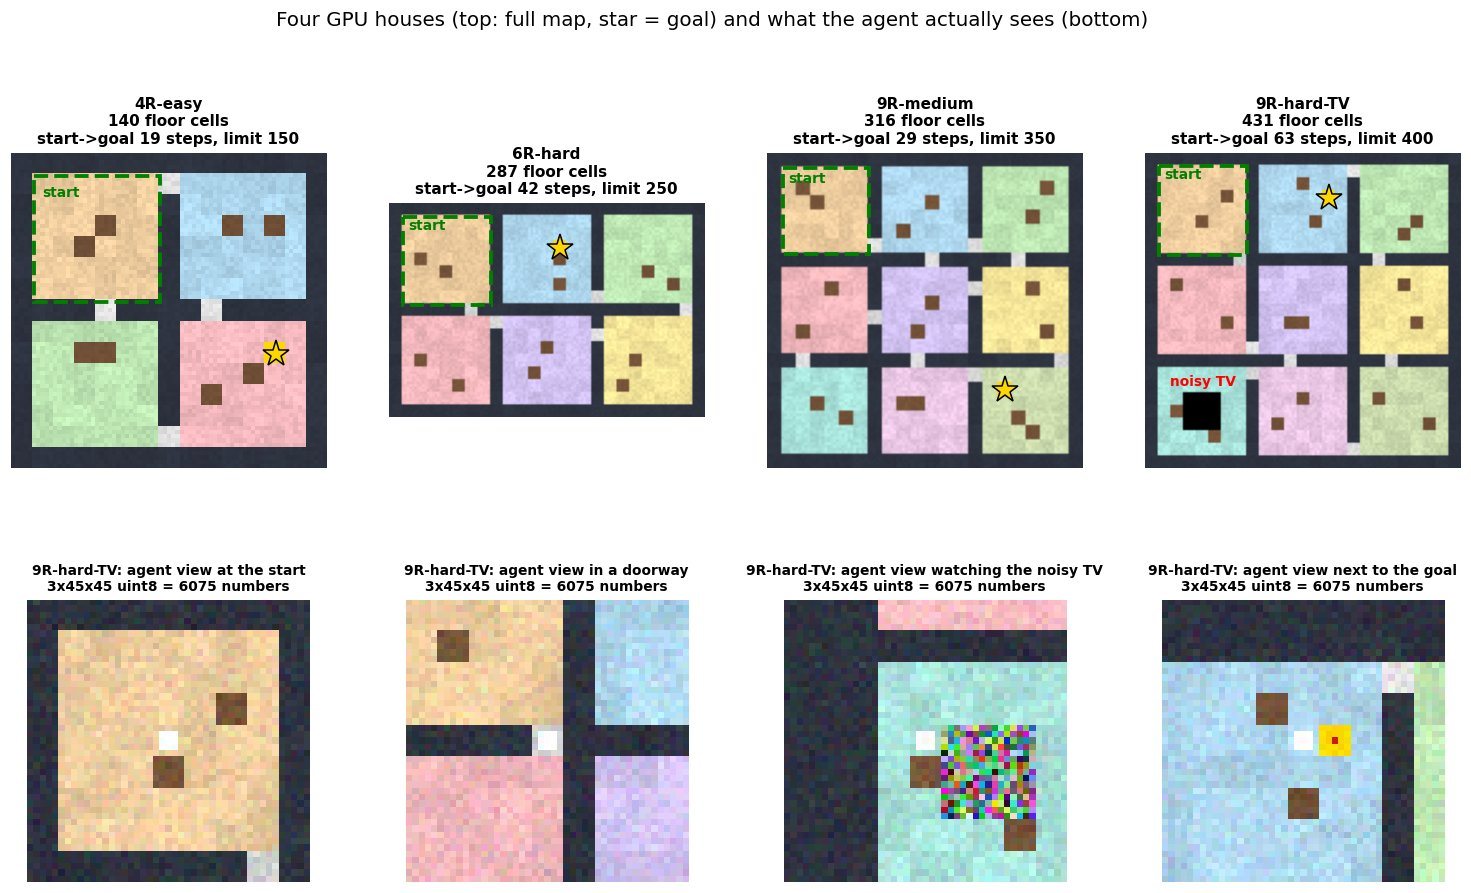

In [16]:
purge(); from lspe.envs import RoomsEnv, LEVELS, geodesic
from matplotlib.patches import Rectangle
envs = {lv: RoomsEnv(lv, n_envs=4, device=DEV) for lv in LEVELS}

fig, axes = plt.subplots(2, 4, figsize=(17, 9), gridspec_kw=dict(height_ratios=[1.35, 1], hspace=0.3))
for c, (lv, e) in enumerate(envs.items()):
    L, px = e.layout, e.px
    ax = axes[0, c]; ax.imshow(e.map_rgb); ax.axis("off")
    xs_, ys_ = zip(*L["start_cells"])
    ax.add_patch(Rectangle((min(xs_) * px, min(ys_) * px), (max(xs_) - min(xs_) + 1) * px, (max(ys_) - min(ys_) + 1) * px,
                           fc="none", ec="green", lw=2.5, ls="--"))
    ax.text(min(xs_) * px + 2, min(ys_) * px + 5, "start", color="green", weight="bold", fontsize=9)
    gx, gy = L["goal"]
    ax.plot(gx * px + px / 2, gy * px + px / 2, "*", ms=18, mec="k", mfc="gold")
    if L["tv_cells"]:
        x0 = min(t[0] for t in L["tv_cells"]) * px; y0 = min(t[1] for t in L["tv_cells"]) * px
        ax.text(x0 + 1.5 * px, y0 - px * 0.6, "noisy TV", color="red", ha="center", fontsize=9, weight="bold")
    D = geodesic(L, L["goal"])
    sd = np.mean([D[y, x] for x, y in L["start_cells"]])
    ax.set_title(f"{lv}\n{e.n_floor} floor cells\nstart->goal {sd:.0f} steps, limit {e.max_steps}", fontsize=10)

# what the agent actually sees: 4 crops from the 9R-hard-TV house
e = envs["9R-hard-TV"]; L = e.layout
def free_neighbour(cells):
    """First free cell (not wall, furniture or TV) next to any of `cells`."""
    for (x, y) in cells:
        for dx, dy in ((-1, 0), (1, 0), (0, -1), (0, 1)):
            if not L["wall"][y + dy, x + dx] and (x + dx, y + dy) not in cells:
                return x + dx, y + dy
spots = [L["start_cells"][len(L["start_cells"]) // 2], L["doors"][0], free_neighbour(L["tv_cells"]), free_neighbour([L["goal"]])]
names = ["at the start", "in a doorway", "watching the noisy TV", "next to the goal"]
xs = torch.tensor([s[0] for s in spots], device=DEV); ys = torch.tensor([s[1] for s in spots], device=DEV)
obs = e.render(xs, ys).permute(0, 2, 3, 1).cpu().numpy()
for c in range(4):
    ax = axes[1, c]; ax.imshow(obs[c], interpolation="nearest"); ax.axis("off")
    ax.set_title(f"9R-hard-TV: agent view {names[c]}\n3x45x45 uint8 = 6075 numbers", fontsize=9)
fig.suptitle("Four GPU houses (top: full map, star = goal) and what the agent actually sees (bottom)", y=0.99, fontsize=13)
show(fig, "p1_houses")


4R-easy      random-walk success   1.0%   per-episode coverage  22.1%   env speed    184k steps/s
6R-hard      random-walk success   0.0%   per-episode coverage  15.9%   env speed    382k steps/s
9R-medium    random-walk success   0.1%   per-episode coverage  14.2%   env speed    386k steps/s
9R-hard-TV   random-walk success   0.0%   per-episode coverage  12.8%   env speed    302k steps/s


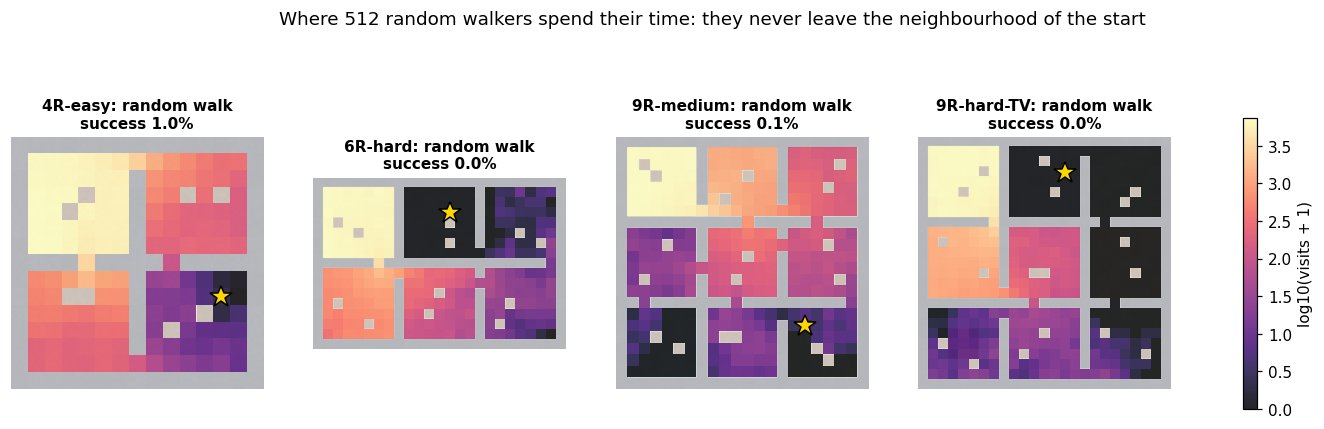

In [17]:
# How hard is each house for pure random exploration? 512 random walkers per house, 2 full episodes each.
rw = {}
for lv in LEVELS:
    e = RoomsEnv(lv, n_envs=512, device=DEV, seed=0)
    succ, cov, t0 = [], [], time.time()
    for _ in range(2 * e.max_steps):
        _, r, d, info = e.step(torch.randint(0, 4, (512,), device=DEV))
        if info:
            succ.append(info["success"]); cov.append(info["ep_cov"])
    succ, cov = torch.cat(succ), torch.cat(cov)
    sps = 512 * 2 * e.max_steps / (time.time() - t0)
    rw[lv] = dict(success=succ.mean().item(), ep_cov=cov.mean().item(), visits=e.visits.cpu().numpy(), sps=sps)
    print(f"{lv:11s}  random-walk success {100*succ.mean():5.1f}%   per-episode coverage {100*cov.mean():5.1f}%   env speed {sps/1e3:6.0f}k steps/s")

fig, axes = plt.subplots(1, 4, figsize=(17, 4.3))
for ax, lv in zip(axes, LEVELS):
    e = envs[lv]; v = rw[lv]["visits"].astype(float); v[e.layout["wall"]] = np.nan
    ax.imshow(e.map_rgb, alpha=0.35, extent=(0, e.W, e.H, 0))
    im = ax.imshow(np.log10(v + 1), cmap="magma", alpha=0.85, extent=(0, e.W, e.H, 0))
    gx, gy = e.layout["goal"]; ax.plot(gx + .5, gy + .5, "*", ms=15, mfc="gold", mec="k")
    ax.set_title(f"{lv}: random walk\nsuccess {100*rw[lv]['success']:.1f}%", fontsize=10); ax.axis("off")
fig.colorbar(im, ax=axes, shrink=0.8, label="log10(visits + 1)")
fig.suptitle("Where 512 random walkers spend their time: they never leave the neighbourhood of the start", y=1.03)
show(fig, "p1_random_walk")


**Reading the numbers.** Random walkers almost never reach a goal that is 19 to 63 steps away, and each episode covers only 13 to 22% of the house. The heatmaps show them buzzing around the start room. Any agent that learns here must first *find* the goal, and exploration is exactly what LSPE is about. Note also the speed: the batched GPU house steps at about 300k frames/s, so the neural networks, not the simulator, set the training speed.

---
## Part 2: Why a *diffusion* model for foresight?

LSPE gives the agent "foresight" with a **Diffusion-based Self-Predictive Network (D-SPN)**, written ψ. Given the current state `s_t`, it predicts the state `k` steps later, `s_{t+k}`. Paper §4.2 argues that the older way, **regressing** the future with a mean-squared-error loss (World Models, PlaNet), *"collapses diverse futures into a single prediction"*.

The reason is simple. MSE is minimised by the **conditional mean**. If an agent in a doorway goes left half the time and right half the time, the mean future is *in the wall between the two rooms*. That is a state that never happens.

A DDPM (Ho et al. 2020) instead learns to **sample** from `p(s_{t+k} | s_t)`:

* **Forward process (Eq. 4):** blend the true future with Gaussian noise, `x_n = sqrt(ᾱ_n)·x_0 + sqrt(1-ᾱ_n)·ε`. At `n = N` it is pure noise.
* **Training (Eq. 5):** a network `ε_ψ(x_n, n, s_t)` learns to guess the noise `ε` that was mixed in: `L = ||ε_ψ(x_n, n, s_t) - ε||²`.
* **Sampling:** start from pure noise and repeatedly subtract the predicted noise. Different starting noise gives *different* futures, so M samples trace out the whole distribution, both doors included.

The spread of those M samples is the uncertainty `Σ_t` that the exploration reward uses in Part 3.

**Our reading of one detail.** The paper's text says ψ corrupts the future *observation*. But Eq. 9 feeds ψ's samples through the encoder φ, and Theorem 2 states the D-SPN posterior directly in latent space: `p(z_{t+k} | s_t) = N(μ_t, Σ_t)`. Generating 6075-number pixel frames 8 times per step is also far too slow for RL. So our ψ is a **latent** diffusion model. It generates the future latent `z_{t+k} = φ_target(s_{t+k})` (32 numbers), conditioned on the current latent `φ(s_t)`.

The module below holds all the networks. The toy that follows it shows the mean-vs-sample difference on data we can plot.

In [81]:
%%writefile /kaggle/working/lspe/lspe/nets.py
"""Networks shared by every agent: the pixel encoder phi, the actor-critic heads, NoisyNet layers,
and the conditional latent diffusion model psi (the paper's D-SPN)."""
import math, torch, torch.nn as nn, torch.nn.functional as F


class ConvTrunk(nn.Module):
    """Pixels (B,3,45,45) -> 4096 features. Spatial size 45 -> 21 -> 10 -> 8.
    uint8 input is scaled to [0,1]; float input (e.g. RND's normalised pixels) is used as is."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 5, 2), nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2), nn.ReLU(),
            nn.Conv2d(64, 64, 3, 1), nn.ReLU(), nn.Flatten())

    def forward(self, x):
        return self.net(x.float() / 255.0 if x.dtype == torch.uint8 else x)


class Encoder(nn.Module):
    """phi: 6075 pixels -> a d-dimensional latent state z (d = 32).
    The final LayerNorm has NO learnable gain, so every latent has the same length sqrt(d). Two measured
    collapses forced this (Part 5): without a LayerNorm, LSPE's losses shrank all latents to one point; with a
    learnable gain, they shrank the gain instead. A fixed-length latent can only 'collapse' by pointing every
    state in the same direction, which the policy loss resists."""
    def __init__(self, d=32):
        super().__init__()
        self.trunk = ConvTrunk()
        self.head = nn.Sequential(nn.Linear(4096, 256), nn.ReLU(), nn.Linear(256, d), nn.LayerNorm(d, elementwise_affine=False))

    def forward(self, x):
        return self.head(self.trunk(x))


class NoisyLinear(nn.Module):
    """Factorised-Gaussian NoisyNet layer (Fortunato et al. 2018): w = mu + sigma * f(eps_out) f(eps_in)^T."""
    def __init__(self, i, o, sigma0=0.5):
        super().__init__()
        bound = 1 / math.sqrt(i)
        self.mu_w = nn.Parameter(torch.empty(o, i).uniform_(-bound, bound))
        self.mu_b = nn.Parameter(torch.empty(o).uniform_(-bound, bound))
        self.sig_w = nn.Parameter(torch.full((o, i), sigma0 / math.sqrt(i)))
        self.sig_b = nn.Parameter(torch.full((o,), sigma0 / math.sqrt(i)))
        self.register_buffer("eps_i", torch.zeros(i))
        self.register_buffer("eps_o", torch.zeros(o))
        self.reset_noise()

    @staticmethod
    def _f(x):
        return x.sign() * x.abs().sqrt()

    def reset_noise(self):
        self.eps_i.normal_(); self.eps_o.normal_()

    def forward(self, x):
        ei, eo = self._f(self.eps_i), self._f(self.eps_o)
        return F.linear(x, self.mu_w + self.sig_w * torch.outer(eo, ei), self.mu_b + self.sig_b * eo)


class ActorCritic(nn.Module):
    """pi(a | phi(s)) and V(phi(s)) (Algorithm 1, line 5). The encoder is shared, so policy and value
    gradients shape phi too, exactly as in a standard pixel PPO agent."""
    def __init__(self, n_act=4, d=32, noisy=False):
        super().__init__()
        self.enc = Encoder(d)
        L = NoisyLinear if noisy else nn.Linear
        self.pi = nn.Sequential(nn.Linear(d, 256), nn.ReLU(), L(256, n_act))
        self.v = nn.Sequential(nn.Linear(d, 256), nn.ReLU(), L(256, 1))

    def forward(self, obs):
        z = self.enc(obs)
        return z, self.pi(z), self.v(z).squeeze(-1)

    def reset_noise(self):
        for m in self.modules():
            if isinstance(m, NoisyLinear):
                m.reset_noise()


def sinusoid(n, dim=64):
    """Standard transformer-style embedding of the integer noise level n."""
    half = dim // 2
    f = torch.exp(-math.log(10000) * torch.arange(half, device=n.device) / half)
    a = n.float()[:, None] * f[None]
    return torch.cat([a.sin(), a.cos()], -1)


class Denoiser(nn.Module):
    """eps_psi(x_n, n, c): guesses the Gaussian noise that was mixed into a future latent x_0, given the
    noisy latent x_n, the noise level n and the condition c (the current latent state)."""
    def __init__(self, d=32, c_dim=32, h=256, blocks=3):
        super().__init__()
        self.inp = nn.Linear(d + c_dim, h)
        self.temb = nn.Sequential(nn.Linear(64, h), nn.SiLU(), nn.Linear(h, h))
        self.blocks = nn.ModuleList([nn.Sequential(nn.LayerNorm(h), nn.Linear(h, h), nn.SiLU(), nn.Linear(h, h))
                                     for _ in range(blocks)])
        self.out = nn.Sequential(nn.LayerNorm(h), nn.Linear(h, d))

    def forward(self, x, n, c):
        hdn = self.inp(torch.cat([x, c], -1)) + self.temb(sinusoid(n))
        for b in self.blocks:
            hdn = hdn + b(hdn)
        return self.out(hdn)


class LatentDDPM(nn.Module):
    """D-SPN: a conditional DDPM over future latents (paper Eq. 4-5).

    forward  x_n = sqrt(abar_n) x_0 + sqrt(1 - abar_n) eps          (Eq. 4; the paper writes abar_n as alpha_n)
    train    || eps_psi(x_n, n, c) - eps ||^2                        (Eq. 5)
    sample   x_N ~ N(0, I), then denoise. We use a strided deterministic DDIM sampler, so one prediction
             costs `steps` network calls (10) instead of N = 50. Different starting noise -> different futures.
    """
    def __init__(self, d=32, c_dim=32, N=50, h=256):
        super().__init__()
        self.d, self.N = d, N
        self.eps = Denoiser(d, c_dim, h)
        s = 0.008
        t = torch.arange(N + 1) / N
        f = torch.cos((t + s) / (1 + s) * math.pi / 2) ** 2
        self.register_buffer("abar", (f[1:] / f[0]).clamp(1e-4, 0.9999))   # Nichol & Dhariwal cosine schedule

    def q_sample(self, x0, n, eps):
        a = self.abar[n][:, None]
        return a.sqrt() * x0 + (1 - a).sqrt() * eps

    def loss(self, x0, c):
        n = torch.randint(0, self.N, (x0.shape[0],), device=x0.device)
        eps = torch.randn_like(x0)
        return F.mse_loss(self.eps(self.q_sample(x0, n, eps), n, c), eps)

    @torch.no_grad()
    def sample(self, c, M=8, steps=10, traj=False, clip=6.0):
        """M sampled futures for every condition row -> (M, B, d). With traj=True also the denoising path."""
        B = c.shape[0]
        cc = c.repeat(M, 1)
        x = torch.randn(M * B, self.d, device=c.device)
        ns = torch.linspace(self.N - 1, 0, steps, device=c.device).round().long()
        path = [x.view(M, B, -1)]
        for i, n in enumerate(ns):
            a = self.abar[n]
            e = self.eps(x, n.expand(M * B), cc)
            x0 = ((x - (1 - a).sqrt() * e) / a.sqrt()).clamp(-clip, clip)
            if i + 1 < steps:
                e = (x - a.sqrt() * x0) / (1 - a).sqrt()          # noise consistent with the clipped x0
                a2 = self.abar[ns[i + 1]]
                x = a2.sqrt() * x0 + (1 - a2).sqrt() * e
            else:
                x = x0
            path.append(x.view(M, B, -1))
        out = x.view(M, B, -1)
        return (out, torch.stack(path)) if traj else out


Overwriting /kaggle/working/lspe/lspe/nets.py


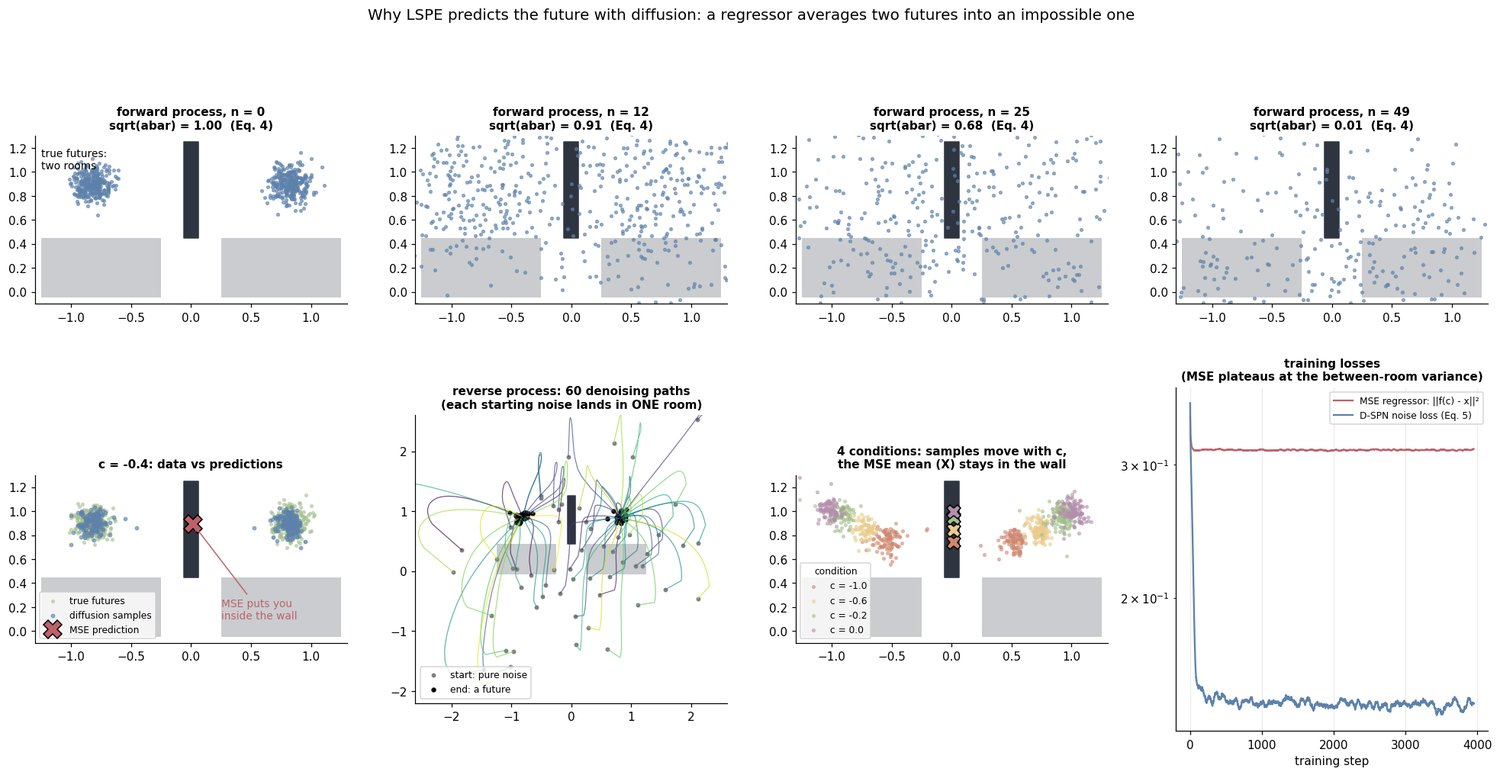

MSE prediction at c=-0.4: x = +0.016 (the wall is |x| < 0.06); diffusion samples: 43% left room, 57% right room, 0.0% near the wall


In [19]:
purge(); from lspe.nets import LatentDDPM
import torch.nn as nn, torch.nn.functional as F
torch.manual_seed(0)

# A T-junction. The agent walks up a corridor; c in [-1, 0] is how far along it is.
# k steps later it is in the LEFT room or the RIGHT room with equal odds. A wall separates the rooms at x = 0.
def futures(c):
    side = torch.randint(0, 2, c.shape, device=c.device).float() * 2 - 1
    reach = 0.55 + 0.45 * (c + 1)                                  # closer to the junction -> deeper into a room
    x = side * reach + 0.07 * torch.randn_like(c)
    y = 0.75 + 0.25 * (c + 1) + 0.07 * torch.randn_like(c)
    return torch.stack([x, y], -1)

mse_net = nn.Sequential(nn.Linear(1, 128), nn.SiLU(), nn.Linear(128, 128), nn.SiLU(), nn.Linear(128, 2)).to(DEV)
ddpm = LatentDDPM(d=2, c_dim=1, N=50, h=128).to(DEV)
opt = torch.optim.Adam(list(mse_net.parameters()) + list(ddpm.parameters()), lr=1e-3)
hist = {"mse": [], "ddpm": []}
for it in range(4000):
    c = -torch.rand(2048, device=DEV); x0 = futures(c)
    l_mse = F.mse_loss(mse_net(c[:, None]), x0)
    l_dd = ddpm.loss(x0, c[:, None])
    opt.zero_grad(); (l_mse + l_dd).backward(); opt.step()
    hist["mse"].append(l_mse.item()); hist["ddpm"].append(l_dd.item())

def room_walls(ax):
    ax.fill_between([-0.06, 0.06], 0.45, 1.25, color="#2e3440", zorder=0)          # wall between the rooms
    ax.fill_between([-1.25, -0.25], -0.05, 0.45, color="#2e3440", alpha=0.25, lw=0)
    ax.fill_between([0.25, 1.25], -0.05, 0.45, color="#2e3440", alpha=0.25, lw=0)
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-0.1, 1.3); ax.set_aspect("equal"); ax.grid(False)

fig, axes = plt.subplots(2, 4, figsize=(18, 9.2))
c0 = torch.full((600,), -0.4, device=DEV); x0 = futures(c0)
for ax, n in zip(axes[0], [0, 12, 25, 49]):
    xn = ddpm.q_sample(x0, torch.full((600,), n, device=DEV), torch.randn_like(x0)).cpu()
    room_walls(ax); ax.scatter(*xn.T, s=6, c="#5e81ac", alpha=0.6)
    ax.set_title(f"forward process, n = {n}\nsqrt(abar) = {ddpm.abar[n].sqrt():.2f}  (Eq. 4)", fontsize=10)
axes[0, 0].text(-1.25, 1.2, "true futures:\ntwo rooms", fontsize=9, va="top")

ax = axes[1, 0]; room_walls(ax)
ax.scatter(*x0.cpu().T, s=6, c="#a3be8c", alpha=0.5, label="true futures")
samp = ddpm.sample(c0[:300, None], M=1, steps=20)[0].cpu()
ax.scatter(*samp.T, s=8, c="#5e81ac", alpha=0.6, label="diffusion samples")
pm = mse_net(c0[:1, None]).detach().cpu()[0]
ax.plot(*pm, "X", ms=16, c="#bf616a", mec="k", label="MSE prediction")
ax.annotate("MSE puts you\ninside the wall", pm.numpy(), (0.25, 0.1), fontsize=9, color="#bf616a",
            arrowprops=dict(arrowstyle="->", color="#bf616a"))
ax.legend(loc="lower left", fontsize=8); ax.set_title("c = -0.4: data vs predictions", fontsize=10)

ax = axes[1, 1]; room_walls(ax)
_, path = ddpm.sample(c0[:60, None], M=1, steps=20, traj=True)
path = path[:, 0].cpu()                                            # (steps+1, 60, 2)
for i in range(60):
    ax.plot(path[:, i, 0], path[:, i, 1], c=plt.cm.viridis(i / 60), lw=0.8, alpha=0.7)
ax.scatter(*path[0].T, s=8, c="grey", label="start: pure noise"); ax.scatter(*path[-1].T, s=10, c="k", label="end: a future")
ax.set_xlim(-2.6, 2.6); ax.set_ylim(-2.2, 2.6); ax.legend(fontsize=8, loc="lower left")
ax.set_title("reverse process: 60 denoising paths\n(each starting noise lands in ONE room)", fontsize=10)

ax = axes[1, 2]; room_walls(ax)
for cv, col in zip([-1.0, -0.6, -0.2, 0.0], ["#d08770", "#ebcb8b", "#a3be8c", "#b48ead"]):
    cc = torch.full((200, 1), cv, device=DEV)
    s = ddpm.sample(cc, M=1, steps=20)[0].cpu(); p = mse_net(cc[:1]).detach().cpu()[0]
    ax.scatter(*s.T, s=6, color=col, alpha=0.5, label=f"c = {cv}")
    ax.plot(*p, "X", ms=12, color=col, mec="k")
ax.legend(fontsize=8, loc="lower left", title="condition", title_fontsize=8)
ax.set_title("4 conditions: samples move with c,\nthe MSE mean (X) stays in the wall", fontsize=10)

ax = axes[1, 3]
k = 50
ax.plot(np.convolve(hist["mse"], np.ones(k) / k, "valid"), label="MSE regressor: ||f(c) - x||²", c="#bf616a")
ax.plot(np.convolve(hist["ddpm"], np.ones(k) / k, "valid"), label="D-SPN noise loss (Eq. 5)", c="#5e81ac")
ax.set_yscale("log"); ax.set_xlabel("training step"); ax.legend(fontsize=8)
ax.set_title("training losses\n(MSE plateaus at the between-room variance)", fontsize=10)
fig.suptitle("Why LSPE predicts the future with diffusion: a regressor averages two futures into an impossible one", fontsize=13, y=1.0)
fig.tight_layout(); show(fig, "p2_why_diffusion")

d_mse = mse_net(c0[:1, None]).detach().cpu()[0]
print(f"MSE prediction at c=-0.4: x = {d_mse[0]:+.3f} (the wall is |x| < 0.06); diffusion samples: "
      f"{(samp[:, 0] < 0).float().mean():.0%} left room, {(samp[:, 0] > 0).float().mean():.0%} right room, "
      f"{(samp[:, 0].abs() < 0.2).float().mean():.1%} near the wall")


**What the toy shows.** The MSE regressor's prediction sits at x ≈ 0, *inside the wall*, for every condition. It learned the average of two futures, which is a place nobody ever goes. The diffusion model's samples split between the two rooms, 0% land near the wall, and they slide deeper into the rooms as `c` moves closer to the junction. The reverse-process panel shows why sampling works: each starting noise vector is carried by the learned denoiser into **one** room. The spread of many samples therefore measures real uncertainty about the future. LSPE's exploration reward is built from exactly that spread.

---
## Part 3: The exploration reward (ERF), geometrically

LSPE's intrinsic reward (§4.3) multiplies two things:

* **Directed progress.** The step the agent just took in latent space (Eq. 8): `Δ_t = h(s_t) - h(s_{t+1})`, where `h` is the temporal-aware embedding (Part 4).
* **Uncertainty along a direction.** Draw `M` futures from D-SPN and take their covariance, `Σ_t = Cov[ẑ^(1..M)_{t+k}]` (Eq. 9).

Pick a random unit direction `z` on the sphere. Algorithm 1 samples it **once per episode**. Then

$$F(s_t, s_{t+1}, z) = \underbrace{\langle \Delta_t, z\rangle^2}_{\text{moved along } z} \times \underbrace{\langle \Sigma_t z, z\rangle}_{\text{future uncertain along } z} \qquad \text{(Eq. 10)}$$

It is large only if the agent **moved along z** *and* the model is **unsure about the future along z**. Standing still (`Δ = 0`) pays nothing. So does moving through well-understood territory (`Σ ≈ 0`). As the model learns a region, `Σ` shrinks and the reward there fades.

**Theorem 2** gives the average over directions in closed form: `E_z[F] = (||Δ||²·tr Σ + 2·ΔᵀΣΔ) / (d(d+2))` (Eq. 11). Below we check it numerically in d = 32. We also measure something the paper does not discuss. Since the policy never sees `z`, one episode's reward is a **single-direction sample** of this average, and we measure how noisy that sample is.

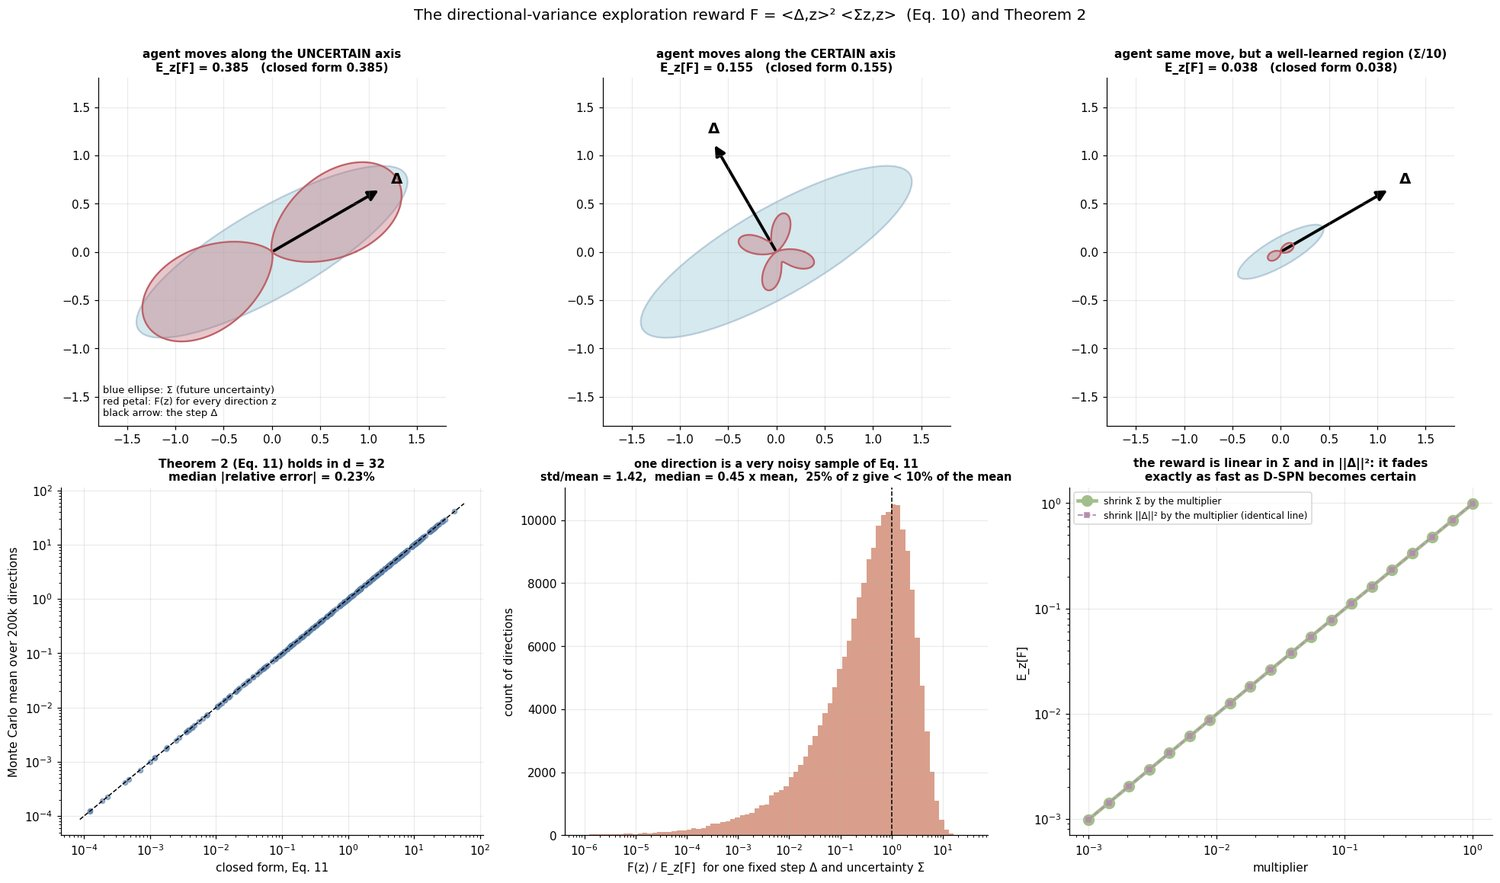

Theorem 2 check: max |relative error| over 300 random (Δ,Σ) = 0.99% (Monte Carlo noise with 200k directions)
single-direction noise in d=32: std/mean = 1.42


In [51]:
from matplotlib.patches import Ellipse, FancyArrowPatch
def erf(delta, Sigma, z):
    """Eq. 10 for many directions z (n,d) at once."""
    return (z @ delta) ** 2 * ((z @ Sigma) * z).sum(-1)
def erf_closed(delta, Sigma):
    d = delta.shape[0]
    return (delta @ delta * torch.trace(Sigma) + 2 * delta @ Sigma @ delta) / (d * (d + 2))
def unit(n, d, dev=DEV):
    z = torch.randn(n, d, device=dev); return z / z.norm(dim=1, keepdim=True)

fig = plt.figure(figsize=(18, 10.5))
th = torch.linspace(0, 2 * np.pi, 721)
U2 = torch.stack([th.cos(), th.sin()], 1)
R = lambda a: torch.tensor([[np.cos(a), -np.sin(a)], [np.sin(a), np.cos(a)]], dtype=torch.float32)
rot = R(np.deg2rad(30)); S0 = rot @ torch.diag(torch.tensor([1.0, 0.08])) @ rot.T
cases = [("moves along the UNCERTAIN axis", rot @ torch.tensor([1.0, 0.0]), S0),
         ("moves along the CERTAIN axis", rot @ torch.tensor([0.0, 1.0]), S0),
         ("same move, but a well-learned region (Σ/10)", rot @ torch.tensor([1.0, 0.0]), S0 / 10)]
Fmax = max(erf(dl, S, U2).max().item() for _, dl, S in cases)
for i, (title, dl, S) in enumerate(cases):
    ax = fig.add_subplot(2, 3, i + 1)
    F2 = erf(dl, S, U2)
    ev, evec = torch.linalg.eigh(S)
    ang = float(np.degrees(np.arctan2(evec[1, 1].item(), evec[0, 1].item())))
    ax.add_patch(Ellipse((0, 0), 2 * ev[1].sqrt().item() * 1.6, 2 * ev[0].sqrt().item() * 1.6, angle=ang,
                         fc="#88c0d0", alpha=0.35, ec="#5e81ac", lw=1.5))
    pts = U2 * (F2 / Fmax)[:, None] * 1.5
    ax.fill(pts[:, 0], pts[:, 1], color="#bf616a", alpha=0.35); ax.plot(pts[:, 0], pts[:, 1], c="#bf616a", lw=1.5)
    ax.add_patch(FancyArrowPatch((0, 0), tuple((dl * 1.3).tolist()), arrowstyle="-|>", mutation_scale=18, lw=2.5, color="k"))
    ax.text(*(dl * 1.42).tolist(), "Δ", fontsize=13, weight="bold")
    ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.8, 1.8); ax.set_aspect("equal")
    mc = erf(dl, S, unit(200000, 2, "cpu")).mean().item()
    ax.set_title(f"agent {title}\nE_z[F] = {mc:.3f}   (closed form {erf_closed(dl, S).item():.3f})", fontsize=10)
    if i == 0:
        ax.text(-1.75, -1.7, "blue ellipse: Σ (future uncertainty)\nred petal: F(z) for every direction z\nblack arrow: the step Δ", fontsize=8.5)

# Theorem 2, d = 32: Monte Carlo over 200k directions vs Eq. 11, for 300 random (Δ, Σ)
d = 32; Z = unit(200000, d)
mc, cf = [], []
g = torch.Generator(device=DEV).manual_seed(0)
for _ in range(300):
    r = int(torch.randint(1, d + 1, (1,), generator=g, device=DEV))
    A = torch.randn(d, r, device=DEV, generator=g) * torch.rand(1, device=DEV, generator=g) * 2
    Sg = A @ A.T / r
    dl = torch.randn(d, device=DEV, generator=g) * torch.rand(1, device=DEV, generator=g) * 3
    mc.append(erf(dl, Sg, Z).mean().item()); cf.append(erf_closed(dl, Sg).item())
mc, cf = np.array(mc), np.array(cf)
ax = fig.add_subplot(2, 3, 4)
ax.loglog(cf, mc, "o", ms=4, alpha=0.6, c="#5e81ac"); lim = [cf.min() * 0.7, cf.max() * 1.4]; ax.plot(lim, lim, "k--", lw=1)
ax.set_xlabel("closed form, Eq. 11"); ax.set_ylabel("Monte Carlo mean over 200k directions")
ax.set_title(f"Theorem 2 (Eq. 11) holds in d = 32\nmedian |relative error| = {np.median(np.abs(mc / cf - 1)):.2%}", fontsize=10)

# How noisy is ONE direction? (the agent sees one z per episode and cannot observe it)
A = torch.randn(d, d, device=DEV); Sg = A @ A.T / d; dl = torch.randn(d, device=DEV)
Fz = erf(dl, Sg, Z).cpu().numpy(); mean = Fz.mean()
ax = fig.add_subplot(2, 3, 5)
ax.hist(Fz / mean, bins=np.logspace(-6, 1.5, 80), color="#d08770", alpha=0.8)
ax.set_xscale("log"); ax.axvline(1, c="k", ls="--", lw=1)
ax.set_xlabel("F(z) / E_z[F]  for one fixed step Δ and uncertainty Σ"); ax.set_ylabel("count of directions")
ax.set_title(f"one direction is a very noisy sample of Eq. 11\nstd/mean = {Fz.std() / mean:.2f},  median = {np.median(Fz) / mean:.2f} x mean,  "
             f"{(Fz < 0.1 * mean).mean():.0%} of z give < 10% of the mean", fontsize=9.5)

# Annealing: shrink the uncertainty and watch the reward fade (linear in Σ)
ax = fig.add_subplot(2, 3, 6)
scales = np.logspace(-3, 0, 20)
ax.loglog(scales, [erf_closed(dl, Sg * s).item() for s in scales], "o-", c="#a3be8c", ms=9, lw=3, label="shrink Σ by the multiplier")
ax.loglog(scales, [erf_closed(dl * s ** 0.5, Sg).item() for s in scales], "s--", c="#b48ead", ms=4, lw=1.2,
          label="shrink ||Δ||² by the multiplier (identical line)")
ax.set_xlabel("multiplier"); ax.set_ylabel("E_z[F]"); ax.legend(fontsize=8)
ax.set_title("the reward is linear in Σ and in ||Δ||²: it fades\nexactly as fast as D-SPN becomes certain", fontsize=10)
fig.suptitle("The directional-variance exploration reward F = <Δ,z>² <Σz,z>  (Eq. 10) and Theorem 2", fontsize=13, y=1.0)
fig.tight_layout(); show(fig, "p3_erf_geometry")
print(f"Theorem 2 check: max |relative error| over 300 random (Δ,Σ) = {np.max(np.abs(mc / cf - 1)):.2%} (Monte Carlo noise with 200k directions)")
print(f"single-direction noise in d=32: std/mean = {Fz.std() / mean:.2f}")


**What the numbers say.**
1. **Theorem 2 (Eq. 11) is exact.** Across 300 random `(Δ, Σ)` pairs in d = 32, the Monte Carlo average over 200k directions matches the closed form to a 0.2% median error, which is pure sampling noise.
2. **The geometry does what the paper says.** Moving along the uncertain axis pays 2.5x more than moving along the certain axis. The same move in a well-learned region (Σ/10) pays 10x less. F is linear in Σ (and in ||Δ||²), so the bonus fades exactly as fast as D-SPN's uncertainty shrinks.
3. **Something the paper does not discuss.** Algorithm 1 draws **one** direction `z` per episode, and the policy `π(a | φ(s))` never sees it. So what the agent actually receives is a single-direction sample of Eq. 11. That sample is very noisy: std/mean ≈ 1.4, the median direction pays under half the mean, and a quarter of directions pay under 10% of it. The policy has to average this noise out across episodes.

*(Eq. 12 also claims `E_z[F] ∝ I(z_{t+k}; Δ_t) + C`. The joint distribution behind that mutual information is only defined in the paper's appendix, which is not in the conference PDF, so we don't test it.)*

---
## Part 4: The agent, piece by piece

```
 pixels s_t (3x45x45) ──φ (CNN)──► z_t (32) ──┬──► π(a|z_t), V(z_t)          PPO, shared encoder
                                              │
                                              ├──► ψ: latent DDPM ──► M=8 futures ẑ^(m)_{t+K}   (Eq. 4-5)
                                              │         mean ẑ_{t+K}      covariance Σ_t        (Eq. 9)
                                              │
                                              └──► h_t = g([z_t, ẑ_{t+K}])   temporal-aware embedding
   F_t = <h_t - h_{t+1}, u>² · <Σ_t u, u>,   u ~ Unif(sphere), one per episode        (Eq. 8, 10)
   r'_t = r_t + β · rank(F_t)                                                          (Eq. 1, Alg. 1 line 8)
```

**Training, following Algorithm 1:**
* **line 9, PPO:** clipped policy loss + value loss + entropy bonus, on the shaped reward `r'`.
* **line 11, D-SPN alone (Eq. 5):** after each rollout, 64 Adam steps of the noise-prediction loss on pairs `(φ(s_t), φ_target(s_{t+K}))` taken from that rollout, only when no reset happens in between. The latents are detached, so **Eq. 5 trains ψ, not the encoder.** Targets are standardised per dimension with running statistics.
* **line 12, joint (Eq. 7):** in every PPO minibatch, the temporal-aware bisimulation loss for random pairs of states `(i, j)`:
  `( d(h_i, h_j) - |r'_i - r'_j| - γ·d(h̄_{i+1}, h̄_{j+1}) )²`, where `d` = mean absolute difference and `h̄` uses the EMA target networks (τ = 0.99). The next-state pair keeps the same predicted future `ψ(s_{i+K})`, exactly as written in Eq. 7. This loss trains the encoder φ and the head g.

**Where the paper is silent, we chose as follows** (flagged so you can change them):

| gap in the paper | our choice | why |
|---|---|---|
| what ψ generates | future **latent** `φ_target(s_{t+K})`, not pixels | Eq. 9 and Theorem 2 live in latent space; 8 pixel frames per step is too slow |
| how `φ(s, ψ(s_{t+k}))` combines its two inputs | a small MLP `g` on `[z_t, mean ẑ_{t+K}]` | the simplest learnable two-input encoder |
| which reward enters Eq. 7 | `r + rank(F)` at unit scale | with sparse `r` alone, `|r_i - r_j| = 0` almost always, so the bisimulation fixed point is **d = 0**: a collapsed metric (the ablation `LSPE w/o ERF` keeps sparse `r`) |
| γ inside Eq. 7 | 0.9 | keeps target distances O(1) for rewards in [0, 1] |
| scale of F vs the task reward | **rank** of F within each rollout, in [0, 1], times **β = 0.01** | every bonus method then pays the same *average* bonus per step and differs only in *where* it pays. This took several tries, see Part 5 |
| horizon K, samples M | K = 8, M = 8, 10 DDIM steps | the paper's Appendix B ablates K but its values are not in the PDF |
| policy input | `π(a | φ(s))`, not given `u` | exactly Algorithm 1, line 5 |

**Baselines:** plain **PPO** (no bonus), **NoisyNet** (noisy policy/value heads, noise resampled each rollout), **RND** (random-network distillation on normalised pixels), **ICM** (inverse-model features plus forward-model error). **Ablations:** **LSPE w/o ERF** (β = 0, all representation losses kept) and **LSPE w MSD** (plain one-step bisimulation on `z` instead of the temporal-aware version). **Our variant:** **LSPE-E**, which pays Eq. 11 (the average over all directions) instead of one random direction per episode. Every method uses the same CNN, the same PPO settings and the same bonus normalisation.

In [99]:
%%writefile /kaggle/working/lspe/lspe/agents.py
"""Exploration bonuses that plug into PPO: LSPE (the paper) and the baselines RND and ICM.

Every bonus exposes the same calls:
  rewards(buf)             -> intrinsic reward F, shape (T,B), computed once per rollout without gradients
  model_update(buf)        -> extra updates of the bonus's own model once per rollout (LSPE: Algorithm 1, line 11)
  aux_loss(buf, t, b, z)   -> (scalar loss, logs) added to PPO's loss on one minibatch; z = phi(s_t) with grad
  after_step()             -> called after every optimizer step (EMA target updates)
"""
import copy, torch, torch.nn as nn, torch.nn.functional as F
from .nets import Encoder, LatentDDPM


def chunked(fn, x, n=4096):
    return torch.cat([fn(x[i:i + n]) for i in range(0, x.shape[0], n)])


@torch.no_grad()
def ema_(target, online, tau):
    for pt, po in zip(target.parameters(), online.parameters()):
        pt.mul_(tau).add_(po.detach(), alpha=1 - tau)


def unit_dirs(n, d, device):
    """n directions drawn uniformly from the unit sphere S^{d-1}."""
    z = torch.randn(n, d, device=device)
    return z / z.norm(dim=1, keepdim=True)


class LSPE(nn.Module):
    """Latent State-Predictive Exploration on top of the agent's shared encoder phi (= ac.enc).

    phi_target : EMA copy of phi, tau = 0.99 (Eq. 7)
    psi        : LatentDDPM. Condition: phi(s_t). Target: phi_target(s_{t+K}), standardised per dimension with
                 running statistics so the diffusion model always sees unit-scale data (Eq. 4-5).
                 Trained ON ITS OWN with Eq. 5 (Algorithm 1, line 11): `dspn_steps` Adam steps per rollout on
                 detached latents. Eq. 5 does not push gradients into phi.
    g          : temporal-aware head, h(s_t) = g([z_t, mean zhat_{t+K}]); our concrete phi(s_t, psi(s_{t+k})).
                 phi and g are trained jointly by the temporal-aware bisimulation loss, Eq. 7 (line 12).
    variant    : "full" = temporal-aware bisimulation (Eq. 6-7)
                 "msd"  = plain one-step bisimulation on z (the paper's 'LSPE w MSD' ablation)
    erf        : "sample" = Eq. 10 with one random direction u per episode (Algorithm 1, as written)
                 "expect" = its average over all directions, the closed form of Theorem 2 (Eq. 11): our LSPE-E
    gamma      : discount inside the bisimulation metric. 0.9 keeps target distances O(1) for rewards in [0,1].
    """

    def __init__(self, enc, d=32, K=8, M=8, steps=10, tau=0.99, gamma=0.9, variant="full", erf="sample",
                 c_bisim=1.0, n_aux=1024, dspn_steps=64, dspn_bs=2048, dspn_lr=5e-4):
        super().__init__()
        self.enc = [enc]                                 # a list, so the shared encoder isn't registered twice
        self.enc_t = copy.deepcopy(enc).requires_grad_(False)
        self.psi = LatentDDPM(d, d)
        self.g = nn.Sequential(nn.Linear(2 * d, 128), nn.ReLU(), nn.Linear(128, d))
        self.g_t = copy.deepcopy(self.g).requires_grad_(False)
        self.register_buffer("mu", torch.zeros(d))
        self.register_buffer("sd", torch.ones(d))
        self.d, self.K, self.M, self.steps, self.tau, self.gamma = d, K, M, steps, tau, gamma
        self.variant, self.erf, self.c_bisim, self.n_aux = variant, erf, c_bisim, n_aux
        self.dspn_steps, self.dspn_bs = dspn_steps, dspn_bs
        self.opt_psi = torch.optim.Adam(self.psi.parameters(), lr=dspn_lr)
        self.stats_init = False
        self.last = {}

    def norm(self, z):
        """Per-dimension standardisation (running stats) of TARGET latents for the diffusion model."""
        return (z - self.mu) / self.sd

    def h(self, z, zhat, target=False):
        """Temporal-aware embedding of a state: its own latent plus D-SPN's predicted future latent."""
        if self.variant == "msd":
            return z
        g = self.g_t if target else self.g
        return g(torch.cat([z, zhat], -1))

    @torch.no_grad()
    def predict(self, z, M=None, steps=None):
        """M sampled futures (M, n, d) for current latents z (n, d), in standardised target units."""
        return torch.cat([self.psi.sample(c, M or self.M, steps or self.steps) for c in z.split(8192)], 1)

    @torch.no_grad()
    def rewards(self, buf):
        obs = buf["obs"]                                                # (T+1, B, 3, 45, 45) uint8
        T1, B = obs.shape[:2]; T = T1 - 1; d = self.d
        z = chunked(self.enc[0], obs.flatten(0, 1))                     # ((T+1)B, d)
        m, s = z.mean(0), z.std(0) + 1e-3
        if not self.stats_init:
            self.mu.copy_(m); self.sd.copy_(s); self.stats_init = True
        else:
            self.mu.lerp_(m, 0.1); self.sd.lerp_(s, 0.1)
        samples = self.predict(z)                                       # (M, (T+1)B, d)  M futures per state
        zhat = samples.mean(0)
        h = self.h(z, zhat).view(T1, B, -1)
        delta = h[:-1] - h[1:]                                          # Eq. 8: latent step s_t -> s_{t+1}
        S = samples[:, :T * B]                                          # futures predicted from s_t
        if self.erf == "sample":
            u = buf["u"].flatten(0, 1)                                  # one unit direction per episode
            unc = torch.einsum("mnd,nd->mn", S, u).var(0)               # u^T Sigma_t u   (Eq. 9)
            F_ = ((delta.flatten(0, 1) * u).sum(-1) ** 2 * unc).view(T, B)            # Eq. 10
        else:
            dl = delta.flatten(0, 1)
            quad = torch.einsum("mnd,nd->mn", S, dl).var(0)             # Delta^T Sigma_t Delta
            F_ = (((dl * dl).sum(-1) * S.var(0).sum(-1) + 2 * quad) / (d * (d + 2))).view(T, B)   # Eq. 11
        F_ = F_ * (1 - buf["done"])                                     # after a reset, s_{t+1} is not a successor
        buf["zhat"] = zhat.view(T1, B, -1)
        buf["z_now"] = z.view(T1, B, -1)
        self.last = dict(trSigma=samples.var(0).sum(-1).mean().item(), delta_norm=delta.norm(dim=-1).mean().item())
        return F_

    def model_update(self, buf):
        """Algorithm 1, line 11: update D-SPN alone with Eq. 5 on (phi(s_t), phi_target(s_{t+K})) pairs."""
        T1, B = buf["obs"].shape[:2]
        tt, bb = buf["valid_k"].nonzero(as_tuple=True)
        if len(tt) == 0:
            return
        with torch.no_grad():
            x0_all = self.norm(chunked(self.enc_t, buf["obs"].flatten(0, 1))).view(T1, B, -1)
        zc = buf["z_now"]
        tot = 0.0
        for _ in range(self.dspn_steps):
            k = torch.randint(0, len(tt), (self.dspn_bs,), device=tt.device)
            l = self.psi.loss(x0_all[tt[k] + self.K, bb[k]], zc[tt[k], bb[k]])
            self.opt_psi.zero_grad(set_to_none=True); l.backward()
            torch.nn.utils.clip_grad_norm_(self.psi.parameters(), 1.0); self.opt_psi.step()
            tot += l.detach()
        self.last["l_dspn"] = float(tot / self.dspn_steps)

    def aux_loss(self, buf, t, b, z):
        """Algorithm 1, line 12: the temporal-aware bisimulation loss (Eq. 7) on random pairs (i, perm(i)).
        Trains phi (through z) and g; the predicted futures psi(s_{i+k}) enter as fixed inputs."""
        obs, done = buf["obs"], buf["done"]
        j = (1 - done[t, b]).nonzero().squeeze(1)[: self.n_aux]
        tj, bj = t[j], b[j]
        zh = buf["zhat"][tj, bj]                                        # psi(s_{j+K})
        hi = self.h(z[j], zh)
        with torch.no_grad():
            h1 = self.h(self.enc_t(obs[tj + 1, bj]), zh, target=True)   # next pair keeps psi(s_{i+k}) (Eq. 7)
        perm = torch.randperm(len(j), device=z.device)
        dist = (hi - hi[perm]).abs().mean(-1)
        dist1 = (h1 - h1[perm]).abs().mean(-1)
        r = buf["r_bisim"][tj, bj]                                      # r + F in unit scale (see train.py)
        l_b = F.mse_loss(dist, (r - r[perm]).abs() + self.gamma * dist1)
        return self.c_bisim * l_b, dict(l_bisim=l_b.detach(), bisim_dist=dist.mean().detach())

    def after_step(self):
        ema_(self.enc_t, self.enc[0], self.tau)
        ema_(self.g_t, self.g, self.tau)


class RND(nn.Module):
    """Random Network Distillation (Burda et al. 2019). Bonus = ||f_pred(s') - f_rand(s')||² on per-pixel
    normalised observations. A frozen random network is easy to imitate on familiar states and hard on novel
    ones, but pure pixel noise (the TV) is never familiar."""

    def __init__(self, d=128, n_aux=1024):
        super().__init__()
        self.target = Encoder(d).requires_grad_(False)
        self.pred = nn.Sequential(Encoder(256), nn.ReLU(), nn.Linear(256, d))
        self.register_buffer("mu", torch.zeros(3, 45, 45))
        self.register_buffer("sd", torch.ones(3, 45, 45))
        self.init, self.n_aux = False, n_aux

    def err(self, o):
        x = ((o.float() - self.mu) / self.sd).clamp(-5, 5)
        return (self.pred(x) - self.target(x)).pow(2).mean(-1)

    @torch.no_grad()
    def rewards(self, buf):
        obs = buf["obs"]; T = obs.shape[0] - 1
        nxt = obs[1:].flatten(0, 1)
        sub = nxt[torch.randint(0, nxt.shape[0], (4096,), device=nxt.device)].float()
        m, s = sub.mean(0), sub.std(0) + 1.0
        if not self.init:
            self.mu.copy_(m); self.sd.copy_(s); self.init = True
        else:
            self.mu.lerp_(m, 0.05); self.sd.lerp_(s, 0.05)
        return chunked(self.err, nxt).view(T, -1) * (1 - buf["done"])

    def model_update(self, buf):
        pass

    def aux_loss(self, buf, t, b, z):
        j = (1 - buf["done"][t, b]).nonzero().squeeze(1)[: self.n_aux]
        l = self.err(buf["obs"][t[j] + 1, b[j]]).mean()
        return l, dict(l_rnd=l.detach())

    def after_step(self):
        pass


class ICM(nn.Module):
    """Intrinsic Curiosity Module (Pathak et al. 2017). Features are trained by an inverse model (which action
    led from s to s'?), so they keep only what the agent can influence. Bonus = forward-model error in them.
    The encoder's final LayerNorm keeps the feature scale bounded."""

    def __init__(self, d=64, n_act=4, n_aux=1024, beta=0.2):
        super().__init__()
        self.feat = Encoder(d)
        self.inv = nn.Sequential(nn.Linear(2 * d, 256), nn.ReLU(), nn.Linear(256, n_act))
        self.fwd = nn.Sequential(nn.Linear(d + n_act, 256), nn.ReLU(), nn.Linear(256, d))
        self.n_act, self.n_aux, self.beta = n_act, n_aux, beta

    def fwd_err(self, f0, a, f1):
        return 0.5 * (self.fwd(torch.cat([f0, F.one_hot(a, self.n_act).float()], -1)) - f1).pow(2).sum(-1)

    @torch.no_grad()
    def rewards(self, buf):
        obs = buf["obs"]; T1, B = obs.shape[:2]
        f = chunked(self.feat, obs.flatten(0, 1)).view(T1, B, -1)
        e = self.fwd_err(f[:-1].flatten(0, 1), buf["act"].flatten(), f[1:].flatten(0, 1)).view(T1 - 1, B)
        return e * (1 - buf["done"])

    def model_update(self, buf):
        pass

    def aux_loss(self, buf, t, b, z):
        j = (1 - buf["done"][t, b]).nonzero().squeeze(1)[: self.n_aux]
        tj, bj = t[j], b[j]
        f0, f1, a = self.feat(buf["obs"][tj, bj]), self.feat(buf["obs"][tj + 1, bj]), buf["act"][tj, bj]
        l_inv = F.cross_entropy(self.inv(torch.cat([f0, f1], -1)), a)
        l_fwd = self.fwd_err(f0, a, f1.detach()).mean()
        return (1 - self.beta) * l_inv + self.beta * l_fwd, dict(l_inv=l_inv.detach(), l_fwd=l_fwd.detach())

    def after_step(self):
        pass


Overwriting /kaggle/working/lspe/lspe/agents.py


In [118]:
%%writefile /kaggle/working/lspe/lspe/train.py
"""One training run: PPO + an exploration bonus in one GPU house.

    python -m lspe.train --level 6R-hard --method lspe --seed 0 --steps 3e6 --out runs/NAME

methods: ppo | noisynet | rnd | icm | lspe | lspe_ev | lspe_noerf | lspe_msd | lspe_ens
  lspe_ev  = LSPE whose reward is Eq. 11 (the average of Eq. 10 over all directions) instead of one random
             direction per episode. Everything else identical.
  lspe_ens = LSPE-E with Sigma taken from the disagreement of 4 D-SPN heads (Part 8, agents_ens.py).
Writes  out/log.jsonl (one line per PPO iteration), out/visits_XX.npy (lifetime visit counts at XX% of
training), out/ckpt_XX.pt (model snapshots), out/eval.npz (final policy's heatmap) and out/done.json.
"""
import argparse, json, os, time, math
import numpy as np, torch
from torch.distributions import Categorical
from .envs import RoomsEnv
from .nets import ActorCritic
from .agents import LSPE, RND, ICM, unit_dirs


def rank01(F, valid):
    """Per-rollout rank transform of a bonus to [0, 1]: the most novel transition of the rollout gets 1, the
    least novel 0. Every method then pays the same average bonus (beta/2 per step) and differs only in WHERE it
    pays. Robust to the heavy tails and the 10-100x scale drift that raw bonuses show while their models fit."""
    out = torch.zeros_like(F)
    x = F[valid]
    if x.numel() > 1:
        r = torch.empty_like(x)
        r[x.argsort()] = torch.linspace(0, 1, x.numel(), device=x.device)
        out[valid] = r
    return out


def erank(z):
    """Effective rank exp(H(p)) of the singular-value distribution: 1 = collapsed, d = all dims used."""
    s = torch.linalg.svdvals(z - z.mean(0))
    p = s / s.sum()
    return float(torch.exp(-(p * torch.log(p + 1e-12)).sum()))


def make(method, level, n_envs, seed, dev, K=8, c_bisim=1.0, gamma_b=0.9, dspn_steps=64):
    env = RoomsEnv(level, n_envs, dev, seed=seed)
    ac = ActorCritic(noisy=method == "noisynet").to(dev)
    if method == "lspe_ens":
        from .agents_ens import LSPEEns
        bonus = LSPEEns(ac.enc, K=K, c_bisim=c_bisim, gamma=gamma_b, dspn_steps=dspn_steps).to(dev)
    elif method.startswith("lspe"):
        bonus = LSPE(ac.enc, K=K, variant="msd" if method == "lspe_msd" else "full",
                     erf="expect" if method == "lspe_ev" else "sample",
                     c_bisim=c_bisim, gamma=gamma_b, dspn_steps=dspn_steps).to(dev)
    elif method == "rnd":
        bonus = RND().to(dev)
    elif method == "icm":
        bonus = ICM().to(dev)
    else:
        bonus = None
    return env, ac, bonus


@torch.no_grad()
def evaluate(ac, level, dev, n_envs=256, episodes=2, seed=123):
    """Run the final stochastic policy with learning off; return success rate, coverage and a visit heatmap."""
    env = RoomsEnv(level, n_envs, dev, seed=seed)
    obs, succ, cov = env.render(), [], []
    for _ in range(episodes * env.max_steps):
        a = Categorical(logits=ac(obs)[1]).sample()
        obs, _, _, info = env.step(a)
        if info:
            succ.append(info["success"]); cov.append(info["ep_cov"])
    return float(torch.cat(succ).mean()), float(torch.cat(cov).mean()), env.visits.cpu().numpy()


def main(a):
    dev = "cuda"
    torch.manual_seed(a.seed); np.random.seed(a.seed)
    torch.set_num_threads(1)                                   # several runs share 4 CPU cores
    torch.backends.cudnn.benchmark = True
    os.makedirs(a.out, exist_ok=True)
    env, ac, bonus = make(a.method, a.level, a.n_envs, a.seed, dev, a.K, a.c_bisim, a.gamma_b, a.dspn_steps)
    beta = 0.0 if a.method in ("ppo", "noisynet", "lspe_noerf") else a.beta
    ac_params = list(ac.parameters())
    bonus_params = ([p for n, p in bonus.named_parameters() if p.requires_grad and not n.startswith("psi.")]
                    if bonus is not None else [])            # LSPE's psi has its own optimizer (Alg. 1 line 11)
    opt = torch.optim.Adam(ac_params + bonus_params, lr=a.lr, eps=1e-5)
    T, B, d = a.T, a.n_envs, 32
    buf = dict(obs=torch.zeros(T + 1, B, 3, env.V, env.V, dtype=torch.uint8, device=dev),
               pos=torch.zeros(T + 1, B, 2, dtype=torch.long, device=dev),
               act=torch.zeros(T, B, dtype=torch.long, device=dev),
               logp=torch.zeros(T, B, device=dev), val=torch.zeros(T, B, device=dev),
               rew=torch.zeros(T, B, device=dev), done=torch.zeros(T, B, device=dev),
               u=torch.zeros(T, B, d, device=dev))
    room = torch.tensor(env.layout["room"], device=dev)
    tv_room, goal_room = env.layout["tv_room"], env.layout["goal_room"]
    obs, u = env.render(), unit_dirs(B, d, dev)
    n_iters = max(1, int(a.steps // (T * B)))
    snaps = {max(0, int(round(n_iters * f)) - 1): f for f in (0.1, 0.25, 0.5, 0.75, 0.9, 1.0)}
    fscale, logf, t_start = None, open(f"{a.out}/log.jsonl", "w"), time.time()
    for it in range(n_iters):
        t0 = time.time()
        if a.method == "noisynet":
            ac.reset_noise()                                   # one noise sample per rollout (and its update)
        ep_s, ep_c, ep_l = [], [], []
        for t in range(T):                                     # ---- collect a rollout
            buf["obs"][t], buf["pos"][t], buf["u"][t] = obs, env.pos(), u
            with torch.no_grad():
                _, logits, v = ac(obs)
            dist = Categorical(logits=logits); act = dist.sample()
            buf["act"][t], buf["logp"][t], buf["val"][t] = act, dist.log_prob(act), v
            obs, r, dn, info = env.step(act)
            buf["rew"][t], buf["done"][t] = r, dn.float()
            if info:
                ep_s.append(info["success"]); ep_c.append(info["ep_cov"]); ep_l.append(info["ep_len"])
                u[dn] = unit_dirs(int(dn.sum()), d, dev)       # Algorithm 1, line 3: fresh z per episode
        buf["obs"][T], buf["pos"][T] = obs, env.pos()
        with torch.no_grad():
            last_v = ac(obs)[2]
        if bonus is not None:                                  # ---- exploration reward
            if isinstance(bonus, LSPE):
                cs = torch.cat([torch.zeros(1, B, device=dev), buf["done"].cumsum(0)])
                tt = torch.arange(T, device=dev)
                tk = (tt + a.K).clamp(max=T)
                buf["valid_k"] = ((cs[tk] - cs[tt]) == 0) & (tt + a.K <= T)[:, None]
            Fr = bonus.rewards(buf)
            bonus.model_update(buf)                            # LSPE: D-SPN alone, Eq. 5 (Alg. 1 line 11)
            valid = buf["done"] == 0
            Fn = rank01(Fr, valid)
            m = float(Fr[valid].mean())
            fscale = m if fscale is None else 0.9 * fscale + 0.1 * m      # raw-scale reference, for plots only
        else:
            Fr = Fn = torch.zeros_like(buf["rew"])
        rs = buf["rew"] + beta * Fn                            # r' = r + F  (Eq. 1)
        buf["r_bisim"] = buf["rew"] + (0.0 if a.method == "lspe_noerf" else 1.0) * Fn   # reward inside Eq. 7
        adv, last = torch.zeros_like(rs), torch.zeros(B, device=dev)
        for t in reversed(range(T)):                           # ---- GAE(lambda)
            nv = last_v if t == T - 1 else buf["val"][t + 1]
            nt = 1 - buf["done"][t]
            last = rs[t] + a.gamma * nv * nt - buf["val"][t] + a.gamma * a.lam * nt * last
            adv[t] = last
        ret = adv + buf["val"]
        fa = adv.flatten(); fa = (fa - fa.mean()) / (fa.std() + 1e-8)
        N = T * B; mb = N // a.n_mb; aux_acc = {}
        for _ in range(a.epochs):                              # ---- PPO update (+ bonus losses)
            perm = torch.randperm(N, device=dev)
            for k in range(a.n_mb):
                idx = perm[k * mb:(k + 1) * mb]; tb, bb = idx // B, idx % B
                z, logits, v = ac(buf["obs"][tb, bb])
                dist = Categorical(logits=logits)
                ratio = (dist.log_prob(buf["act"][tb, bb]) - buf["logp"][tb, bb]).exp()
                A = fa[idx]
                pg = -torch.min(ratio * A, ratio.clamp(1 - a.clip_eps, 1 + a.clip_eps) * A).mean()
                vl = 0.5 * (v - ret[tb, bb]).pow(2).mean()
                ent = dist.entropy().mean()
                loss = pg + a.vf * vl - a.ent * ent
                if bonus is not None:
                    l_aux, logs = bonus.aux_loss(buf, tb, bb, z)
                    loss = loss + l_aux
                    for kk, vv in logs.items():
                        aux_acc[kk] = aux_acc.get(kk, 0) + vv / (a.epochs * a.n_mb)
                opt.zero_grad(set_to_none=True); loss.backward()
                torch.nn.utils.clip_grad_norm_(ac_params, 0.5)            # agent (incl. shared encoder)
                if bonus_params:
                    torch.nn.utils.clip_grad_norm_(bonus_params, 5.0)     # bonus networks, clipped separately
                opt.step()
                if bonus is not None:
                    bonus.after_step()
        # ---- logging
        rooms_now = room[buf["pos"][:T, :, 1], buf["pos"][:T, :, 0]]
        rec = dict(it=it, steps=(it + 1) * T * B, time=time.time() - t_start, fps=T * B / (time.time() - t0),
                   succ=float(torch.cat(ep_s).mean()) if ep_s else float("nan"),
                   ep_cov=float(torch.cat(ep_c).mean()) if ep_c else float("nan"),
                   ep_len=float(torch.cat(ep_l).mean()) if ep_l else float("nan"),
                   glob_cov=env.coverage(), n_eps=sum(len(x) for x in ep_s),
                   F_raw=float(Fr.mean()), F_cv=float(Fr.std() / (Fr.mean() + 1e-12)) if bonus is not None else 0.0,
                   pg=pg.item(), vl=vl.item(), ent=ent.item(), z_spread=float(z.detach().std(0).mean()),
                   goal_room=float((rooms_now == goal_room).float().mean()),
                   tv_room=float((rooms_now == tv_room).float().mean()) if tv_room is not None else 0.0)
        rec.update({k: float(v) for k, v in aux_acc.items()})
        if isinstance(bonus, LSPE):
            rec.update(bonus.last)
        if it % 5 == 0 or it == n_iters - 1:
            rec["erank"] = erank(z.detach().float())
        logf.write(json.dumps(rec) + "\n"); logf.flush()
        if it in snaps:
            f = snaps[it]
            np.save(f"{a.out}/visits_{int(f * 100):03d}.npy", env.visits.cpu().numpy())
            if f in (0.1, 0.25, 0.5, 1.0) and (a.method.startswith("lspe") or f == 1.0):
                torch.save(dict(ac=ac.state_dict(), bonus=bonus.state_dict() if bonus is not None else None,
                                fscale=fscale, steps=rec["steps"]), f"{a.out}/ckpt_{int(f * 100):03d}.pt")
    ev_s, ev_c, ev_v = evaluate(ac, a.level, dev)
    np.savez_compressed(f"{a.out}/eval.npz", visits=ev_v, success=ev_s, coverage=ev_c)
    json.dump(dict(vars(a), eval_success=ev_s, eval_cov=ev_c, minutes=(time.time() - t_start) / 60),
              open(f"{a.out}/done.json", "w"))
    print(f"[done] {a.out}: eval success {ev_s:.3f}, coverage {ev_c:.3f}, {(time.time() - t_start) / 60:.1f} min", flush=True)


def get_args(argv=None):
    p = argparse.ArgumentParser()
    p.add_argument("--level", default="6R-hard"); p.add_argument("--method", default="lspe")
    p.add_argument("--seed", type=int, default=0); p.add_argument("--steps", type=float, default=3e6)
    p.add_argument("--out", default="runs/debug"); p.add_argument("--n_envs", type=int, default=128)
    p.add_argument("--T", type=int, default=128); p.add_argument("--lr", type=float, default=3e-4)
    p.add_argument("--gamma", type=float, default=0.99); p.add_argument("--lam", type=float, default=0.95)
    p.add_argument("--epochs", type=int, default=4); p.add_argument("--n_mb", type=int, default=4)
    p.add_argument("--clip_eps", type=float, default=0.2); p.add_argument("--vf", type=float, default=0.5)
    p.add_argument("--ent", type=float, default=0.01); p.add_argument("--beta", type=float, default=0.01)
    p.add_argument("--K", type=int, default=8)
    p.add_argument("--c_bisim", type=float, default=1.0, help="weight of the bisimulation loss (Eq. 7)")
    p.add_argument("--gamma_b", type=float, default=0.9, help="discount inside the bisimulation metric")
    p.add_argument("--dspn_steps", type=int, default=64, help="D-SPN-only Adam steps per rollout (Alg. 1 line 11)")
    return p.parse_args(argv)


if __name__ == "__main__":
    main(get_args())


Overwriting /kaggle/working/lspe/lspe/train.py


In [45]:
%%writefile /kaggle/working/lspe/lspe/queue.py
"""Run a list of training jobs on one GPU, `--par` at a time, skipping jobs that already finished.
    python -m lspe.queue --gpu 0 --jobs jobs_gpu0.json --par 2
Each job is {"name": ..., "args": [...]} ; output goes to runs/<name>, stdout/stderr to logs/<name>.txt."""
import argparse, json, os, subprocess, sys, time

p = argparse.ArgumentParser()
p.add_argument("--gpu", default="0"); p.add_argument("--jobs"); p.add_argument("--par", type=int, default=2)
a = p.parse_args()
root = os.path.dirname(os.path.dirname(os.path.abspath(__file__)))
jobs = [j for j in json.load(open(a.jobs)) if not os.path.exists(f"{root}/runs/{j['name']}/done.json")]
env = dict(os.environ, CUDA_VISIBLE_DEVICES=a.gpu, PYTHONPATH=root, OMP_NUM_THREADS="1", MKL_NUM_THREADS="1")
running = []
while jobs or running:
    running = [(j, pr) for j, pr in running if pr.poll() is None]
    while jobs and len(running) < a.par:
        j = jobs.pop(0)
        cmd = [sys.executable, "-m", "lspe.train", "--out", f"{root}/runs/{j['name']}"] + j["args"]
        pr = subprocess.Popen(cmd, cwd=root, env=env, stdout=open(f"{root}/logs/{j['name']}.txt", "w"), stderr=subprocess.STDOUT)
        running.append((j, pr))
        print(time.strftime("%H:%M:%S"), "start", j["name"], flush=True)
    time.sleep(5)
print(time.strftime("%H:%M:%S"), "queue finished", flush=True)


Overwriting /kaggle/working/lspe/lspe/queue.py


### The whole machine in one picture

This is our version of the paper's Fig. 3, drawn with the **real tensor shapes and parameter counts** of the modules written above. Solid arrows are the forward pass the agent runs every step. Dashed arrows are training signals.

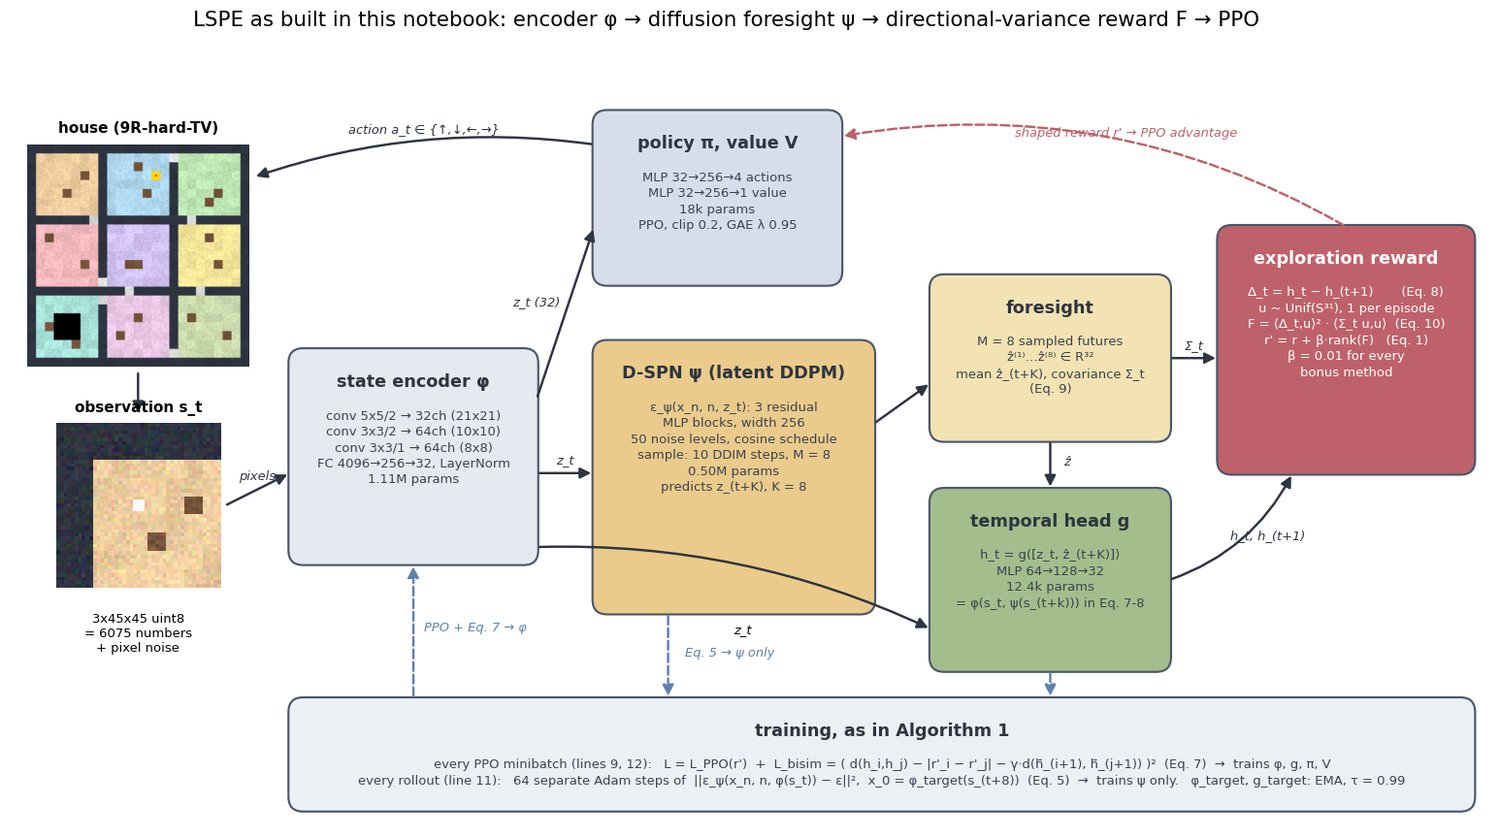

{'enc': '1,114,912', 'pi': '9,476', 'v': '8,705', 'psi': '504,096', 'g': '12,448'} | total trainable: 1,649,637


In [104]:
purge()
from lspe.envs import RoomsEnv
from lspe.nets import ActorCritic
from lspe.agents import LSPE
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
_ac = ActorCritic(); _ls = LSPE(_ac.enc)
npar = lambda m: sum(p.numel() for p in m.parameters())
P = dict(enc=npar(_ac.enc), pi=npar(_ac.pi), v=npar(_ac.v), psi=npar(_ls.psi), g=npar(_ls.g))
_e = RoomsEnv("9R-hard-TV", 1, "cpu")

fig, ax = plt.subplots(figsize=(18, 9)); ax.set_xlim(0, 18); ax.set_ylim(0, 9.0); ax.axis("off")
def box(x, y, w, h, title, body, fc, tc="#2e3440", bc="#3b4252"):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.18", fc=fc, ec="#4c566a", lw=1.4))
    ax.text(x + w / 2, y + h - 0.28, title, ha="center", va="top", fontsize=11.5, weight="bold", color=tc)
    ax.text(x + w / 2, y + h - 0.72, body, ha="center", va="top", fontsize=8.6, color=bc, linespacing=1.35)
def arrow(p, q, txt="", dashed=False, col="#2e3440", rad=0.0, fs=8.5, off=(0, 0.12)):
    ax.add_patch(FancyArrowPatch(p, q, arrowstyle="-|>", mutation_scale=15, lw=1.6, color=col,
                                 ls="--" if dashed else "-", connectionstyle=f"arc3,rad={rad}"))
    if txt:
        ax.text((p[0] + q[0]) / 2 + off[0], (p[1] + q[1]) / 2 + off[1], txt, ha="center", fontsize=fs, color=col, style="italic")

# environment + observation thumbnails
ax.imshow(_e.map_rgb, extent=(0.2, 2.9, 5.6, 8.3)); ax.text(1.55, 8.45, "house (9R-hard-TV)", ha="center", fontsize=10, weight="bold")
ob = _e.render(torch.tensor([3]), torch.tensor([3])).permute(0, 2, 3, 1)[0].numpy()
ax.imshow(ob, extent=(0.55, 2.55, 2.9, 4.9)); ax.text(1.55, 5.05, "observation s_t", ha="center", fontsize=10, weight="bold")
ax.text(1.55, 2.6, "3x45x45 uint8\n= 6075 numbers\n+ pixel noise", ha="center", va="top", fontsize=8.6)
arrow((1.55, 5.55), (1.55, 5.0))

box(3.4, 3.2, 3.0, 2.6, "state encoder φ", f"conv 5x5/2 → 32ch (21x21)\nconv 3x3/2 → 64ch (10x10)\nconv 3x3/1 → 64ch (8x8)\nFC 4096→256→32, LayerNorm\n{P['enc']/1e6:.2f}M params", "#e5e9f0")
arrow((2.6, 3.9), (3.4, 4.3), "pixels")
box(7.1, 6.6, 3.0, 2.1, "policy π, value V", f"MLP 32→256→4 actions\nMLP 32→256→1 value\n{(P['pi'] + P['v'])/1e3:.0f}k params\nPPO, clip 0.2, GAE λ 0.95", "#d8dee9")
arrow((6.4, 5.2), (7.1, 7.3), "z_t (32)", off=(-0.35, 0.1))
arrow((7.1, 8.3), (2.95, 7.9), "action a_t ∈ {↑,↓,←,→}", rad=0.12, off=(0, 0.35))

box(7.1, 2.6, 3.4, 3.3, "D-SPN ψ (latent DDPM)", f"ε_ψ(x_n, n, z_t): 3 residual\nMLP blocks, width 256\n50 noise levels, cosine schedule\nsample: 10 DDIM steps, M = 8\n{P['psi']/1e6:.2f}M params\npredicts z_(t+K), K = 8", "#ebcb8b")
arrow((6.4, 4.3), (7.1, 4.3), "z_t")
box(11.2, 4.7, 2.9, 2.0, "foresight", "M = 8 sampled futures\nẑ⁽¹⁾…ẑ⁽⁸⁾ ∈ R³²\nmean ẑ_(t+K), covariance Σ_t\n(Eq. 9)", "#f3e3b3")
arrow((10.5, 4.9), (11.2, 5.4))
box(11.2, 1.9, 2.9, 2.2, "temporal head g", f"h_t = g([z_t, ẑ_(t+K)])\nMLP 64→128→32\n{P['g']/1e3:.1f}k params\n= φ(s_t, ψ(s_(t+k))) in Eq. 7-8", "#a3be8c")
arrow((12.65, 4.7), (12.65, 4.1), "ẑ", off=(0.2, 0))
arrow((6.4, 3.4), (11.2, 2.4), "", rad=-0.12)
ax.text(8.8, 2.35, "z_t", fontsize=8.5, style="italic")

box(14.7, 4.3, 3.1, 3.0, "exploration reward", "Δ_t = h_t − h_(t+1)       (Eq. 8)\nu ~ Unif(S³¹), 1 per episode\nF = ⟨Δ_t,u⟩² · ⟨Σ_t u,u⟩  (Eq. 10)\nr' = r + β·rank(F)   (Eq. 1)\nβ = 0.01 for every\nbonus method", "#bf616a", tc="white", bc="white")
arrow((14.1, 5.7), (14.7, 5.7), "Σ_t")
arrow((14.1, 3.0), (15.6, 4.3), "h_t, h_(t+1)", rad=0.2, off=(0.45, -0.15))
arrow((16.25, 7.3), (10.1, 8.4), "shaped reward r' → PPO advantage", dashed=True, col="#bf616a", rad=0.18, off=(0.4, 0.55))

box(3.4, 0.2, 14.4, 1.35, "training, as in Algorithm 1",
    "every PPO minibatch (lines 9, 12):   L = L_PPO(r')  +  L_bisim = ( d(h_i,h_j) − |r'_i − r'_j| − γ·d(h̄_(i+1), h̄_(j+1)) )²  (Eq. 7)  →  trains φ, g, π, V\n"
    "every rollout (line 11):   64 separate Adam steps of  ||ε_ψ(x_n, n, φ(s_t)) − ε||²,  x_0 = φ_target(s_(t+8))  (Eq. 5)  →  trains ψ only.   "
    "φ_target, g_target: EMA, τ = 0.99", "#eceff4")
arrow((8.0, 2.6), (8.0, 1.55), "Eq. 5 → ψ only", dashed=True, col="#5e81ac", off=(0.75, 0))
arrow((12.65, 1.9), (12.65, 1.55), "", dashed=True, col="#5e81ac")
arrow((4.9, 1.55), (4.9, 3.2), "PPO + Eq. 7 → φ", dashed=True, col="#5e81ac", off=(0.75, 0))
fig.suptitle("LSPE as built in this notebook: encoder φ → diffusion foresight ψ → directional-variance reward F → PPO", fontsize=14, y=0.96)
show(fig, "p0_architecture")
print({k: f"{v:,}" for k, v in P.items()}, "| total trainable:", f"{sum(P.values()):,}")


In [105]:
# Smoke test: every method for 3 PPO iterations (3 x 16,384 env steps) on 6R-hard. Checks the code runs and
# reports each method's cost (note: measured while the background grid shares the GPUs, so absolute speeds are low).
purge(); from lspe.train import main, get_args
METHODS = ["ppo", "noisynet", "rnd", "icm", "lspe", "lspe_ev", "lspe_noerf", "lspe_msd"]
for m in METHODS:
    out = f"{ROOT}/runs/smoke_{m}"
    t0 = time.time()
    main(get_args(["--level", "6R-hard", "--method", m, "--steps", str(3 * 128 * 128), "--out", out]))
    last = [json.loads(l) for l in open(f"{out}/log.jsonl")][-1]
    keys = [k for k in ("l_dspn", "l_bisim", "bisim_dist", "trSigma", "l_rnd", "l_inv", "l_fwd") if k in last]
    print(f"  {m:10s} {time.time() - t0:5.1f}s total | {last['fps'] / 1e3:5.1f}k steps/s | z_spread {last['z_spread']:.3f} | "
          f"erank {last.get('erank', float('nan')):.1f} | " + " ".join(f"{k}={last[k]:.3f}" for k in keys))


[done] /kaggle/working/lspe/runs/smoke_ppo: eval success 0.000, coverage 0.178, 0.5 min
  ppo         32.4s total |   2.4k steps/s | z_spread 0.221 | erank 11.3 | 
[done] /kaggle/working/lspe/runs/smoke_noisynet: eval success 0.000, coverage 0.102, 0.6 min
  noisynet    34.1s total |   2.2k steps/s | z_spread 0.199 | erank 9.0 | 
[done] /kaggle/working/lspe/runs/smoke_rnd: eval success 0.000, coverage 0.109, 0.6 min
  rnd         36.0s total |   2.1k steps/s | z_spread 0.130 | erank 10.0 | l_rnd=0.041
[done] /kaggle/working/lspe/runs/smoke_icm: eval success 0.000, coverage 0.163, 0.7 min
  icm         39.3s total |   1.7k steps/s | z_spread 0.216 | erank 12.0 | l_inv=1.357 l_fwd=5.725
[done] /kaggle/working/lspe/runs/smoke_lspe: eval success 0.000, coverage 0.171, 0.7 min
  lspe        43.3s total |   1.6k steps/s | z_spread 0.105 | erank 11.7 | l_dspn=0.380 l_bisim=0.084 bisim_dist=0.395 trSigma=384.309
[done] /kaggle/working/lspe/runs/smoke_lspe_ev: eval success 0.000, coverage 0.158

---
## Part 5: Experiments

**Budget reality.** From the smoke test, PPO runs at about 10k env steps/s on one idle T4 and LSPE at about 6k. LSPE costs about 1.7x PPO: 8 diffusion samples x 10 denoising steps for every state, 64 extra D-SPN updates per rollout, and an extra target-encoder pass for Eq. 7. With four runs sharing two T4s and four CPU cores, each run gets about 3k steps/s, so a 3M-step run takes 15 to 20 minutes.

### What went wrong on the way (kept because each is a real lesson about LSPE)

Getting a *fair* comparison took five restarts. Each one fixed something that would have silently decided the result:

1. **Normalising the bonus by its whole-history std silenced every bonus.** Every bonus model starts badly fitted. D-SPN's untrained samples fill the ±6 clip box (tr Σ ≈ 1000), and RND's and ICM's errors start high. The raw bonus then falls 10 to 100x in the first ~300k steps as the models fit. After that transient, `F / std(all F so far)` was about 0.02, so LSPE was really just PPO.
2. **Normalising by a moving std turned ICM into a constant "living reward".** ICM's forward error was high everywhere and varied little, so `F/std` sat at the clip value on every step. That pays the agent for staying alive, the opposite of reaching the goal and ending the episode.
3. **LSPE's encoder collapsed.** After 300k steps the latent of **every one of the 287 cells** was the same vector to within about 0.002. The policy literally could not tell states apart. One push comes from the bisimulation loss (Eq. 7) under sparse reward: `|r_i - r_j| = 0` for almost every pair, so its target distance is ≈ 0. This is exactly the weakness the paper names in §4.1. A LayerNorm on the latent did not help while it had a learnable gain: the losses shrank the gain instead.
4. **The bigger push: we had let Eq. 5 train the encoder.** Our first build added D-SPN's loss (Eq. 5) to the joint minibatch loss, with the encoder's latent as its condition. Behind a per-dimension standardisation `(z - μ)/σ`, that gradient reached the encoder amplified by 1/σ ≈ 25 and swamped PPO's under the shared gradient clip. A switch-one-loss-off test pinned it down: with bisimulation off, D-SPN alone still froze the encoder. Re-reading **Algorithm 1** shows why this was a misreading. **Line 11 updates D-SPN on its own with Eq. 5. Line 12 jointly updates φ and ψ with Eq. 7.** So Eq. 5 should never train the encoder. D-SPN was also badly under-trained: it got only 16 gradient steps per rollout, and at 300k steps its samples were still noise (tr Σ ≈ 860).
5. **Heavy tails.** LSPE's raw bonus is the product of two squared quantities. A handful of transitions carry almost all of it, so any "divide by the mean or std, then clip" scheme ends up paying a few steps and ignoring the rest.

**The final design, applied identically to every method:**
* a **gain-free LayerNorm** on the encoder output, so every latent has the same length and cannot shrink;
* **D-SPN trains alone** (Algorithm 1, line 11): 64 Adam steps per rollout on detached latents, with its own optimiser. The encoder is shaped by PPO and by the bisimulation loss (line 12);
* each rollout's bonus is **rank-normalised** to [0, 1]. The most novel transition in a rollout pays 1 and the least novel pays 0, so every method pays the same average bonus and differs only in *where* it pays. We use one **β = 0.01** for every bonus method;
* for LSPE, the bisimulation's reward is `r + F_rank` at unit scale, so the metric has something to measure. (`LSPE w/o ERF` keeps the sparse `r` alone. It is the ablation that shows what happens without it.)

The cell below re-runs the collapse check with all fixes in place. `z_spread`, the spread of latents across the batch, now grows from 0.08 to 0.7, the same range as PPO's encoder. D-SPN's uncertainty `tr Σ` falls from about 1000 to about 50 within 350k steps: it is now actually learning the future.

### A variant we added: LSPE-E
Part 3 showed that one random direction per episode makes LSPE's reward a very noisy sample (std/mean ≈ 1.4). A policy trained on a mostly-noise reward drifts the way plain PPO does. **LSPE-E** is identical to LSPE except that it pays the direction-averaged reward, which is the closed form of Theorem 2 (Eq. 11). It tests whether Algorithm 1's direction lottery costs anything.

### The grid
Seven methods plus LSPE-E. They run on `6R-hard` (3M steps) and `9R-hard-TV` (3M), then `4R-easy` (1M), then second seeds for the key methods. `LSPE w/o ERF` and `LSPE w MSD` run on `6R-hard` only. Every run writes its log, visit heatmaps, checkpoints and a final evaluation of its policy with learning switched off.

In [102]:
# Collapse check after the fix: LSPE for 24 PPO iterations (~400k steps) on an idle GPU. z_spread must stay healthy.
purge(); from lspe.train import main, get_args
out = f"{ROOT}/runs/smoke_collapse_check"
main(get_args(["--level", "6R-hard", "--method", "lspe", "--steps", str(24 * 128 * 128), "--out", out]))
df = pd.DataFrame([json.loads(l) for l in open(f"{out}/log.jsonl")])
print(df[["it", "z_spread", "erank", "bisim_dist", "l_dspn", "l_bisim", "trSigma", "ep_cov", "fps"]].iloc[::3].to_string(index=False, float_format=lambda x: f"{x:.3f}"))


[done] /kaggle/working/lspe/runs/smoke_collapse_check: eval success 0.000, coverage 0.107, 2.4 min
 it  z_spread  erank  bisim_dist  l_dspn  l_bisim  trSigma  ep_cov      fps
  0     0.077 15.372       0.391   0.517    0.113 1010.960     NaN 2640.020
  3     0.272    NaN       0.406   0.316    0.078  308.302   0.173 3121.923
  6     0.332    NaN       0.514   0.179    0.069  177.667     NaN 2881.452
  9     0.530    NaN       0.638   0.157    0.065  125.270   0.114 3084.174
 12     0.551    NaN       0.729   0.142    0.068  109.558     NaN 2884.541
 15     0.583 11.031       0.796   0.106    0.071   56.199   0.116 3157.645
 18     0.622    NaN       0.836   0.104    0.069   46.742     NaN 2866.389
 21     0.710    NaN       0.872   0.093    0.072   48.450   0.140 2740.618


In [103]:
def job(level, method, seed, steps, beta=0.01, tag=""):
    name = f"{level}__{method}{tag}__s{seed}"
    return dict(name=name, args=["--level", level, "--method", method, "--seed", str(seed),
                                 "--steps", str(int(steps)), "--beta", str(beta)])

def launch(queues, par=2):
    """queues: {gpu_id: [jobs]}. Starts one detached queue process per GPU (safe to re-run: finished jobs are skipped)."""
    procs = {}
    for gpu, jobs in queues.items():
        jf = f"{ROOT}/logs/jobs_gpu{gpu}.json"; json.dump(jobs, open(jf, "w"))
        procs[gpu] = subprocess.Popen([sys.executable, "-m", "lspe.queue", "--gpu", str(gpu), "--jobs", jf, "--par", str(par)],
                                      cwd=ROOT, env=dict(os.environ, PYTHONPATH=ROOT), start_new_session=True,
                                      stdout=open(f"{ROOT}/logs/queue_gpu{gpu}.txt", "a"), stderr=subprocess.STDOUT)
    return procs

# The grid, in priority order. beta = 0.01 for every bonus method (see the notes above for how we got here).
ALL = ["lspe", "lspe_ev", "rnd", "icm", "ppo", "noisynet"]
grid = ([job("6R-hard", m, 0, 3e6) for m in ALL + ["lspe_noerf", "lspe_msd"]] +
        [job("9R-hard-TV", m, 0, 3e6) for m in ALL] +
        [job("4R-easy", m, 0, 1e6) for m in ALL] +
        [job("6R-hard", m, 1, 3e6) for m in ["lspe", "lspe_ev", "rnd", "ppo", "icm"]] +
        [job("9R-hard-TV", m, 1, 3e6) for m in ["lspe", "lspe_ev", "rnd", "ppo"]])
todo = [j for j in grid if not os.path.exists(f"{ROOT}/runs/{j['name']}")]   # skip finished or already-running runs
qprocs = launch({0: todo[0::2], 1: todo[1::2]}, par=2)
print(f"{len(grid)} runs in the grid, {len(todo)} launched now (2 at a time per GPU):", {g: p.pid for g, p in qprocs.items()})


29 runs in the grid, 27 launched now (2 at a time per GPU): {0: 1175, 1: 1176}


In [124]:
import pandas as pd
def load(name):
    p = f"{ROOT}/runs/{name}/log.jsonl"
    if not os.path.exists(p):
        return None
    return pd.DataFrame([json.loads(l) for l in open(p) if l.strip()])

def status(pattern="*"):
    """One line per run: progress and the latest (smoothed over 10 iterations) metrics."""
    rows = []
    for d in sorted(glob.glob(f"{ROOT}/runs/{pattern}")):
        name = os.path.basename(d)
        if name.startswith("smoke"):
            continue
        df = load(name)
        if df is None or len(df) == 0:
            rows.append(dict(run=name, state="starting")); continue
        tail = df.tail(10)
        rows.append(dict(run=name, state="DONE" if os.path.exists(f"{d}/done.json") else "run",
                         Msteps=df.steps.iloc[-1] / 1e6, succ=tail.succ.mean(), ep_cov=tail.ep_cov.mean(),
                         glob_cov=df.glob_cov.iloc[-1], goal_room=tail.goal_room.mean(), tv_room=tail.tv_room.mean(),
                         z_spread=tail.z_spread.mean(), erank=df.erank.dropna().iloc[-1],
                         kfps=tail.fps.mean() / 1e3, min=df.time.iloc[-1] / 60))
    return pd.DataFrame(rows)

print(datetime.datetime.now().strftime("%H:%M:%S"))
print(status().to_string(index=False, float_format=lambda x: f"{x:.3f}"))


02:32:59
                     run state  Msteps  succ  ep_cov  glob_cov  goal_room  tv_room  z_spread  erank   kfps    min
        4R-easy__icm__s0  DONE   0.999 0.001   0.192     1.000      0.000    0.000     0.501  9.085  2.806  6.517
       4R-easy__lspe__s0  DONE   0.999 1.000   0.153     1.000      0.329    0.000     0.829 17.358  2.740  6.238
    4R-easy__lspe_ev__s0  DONE   0.999 1.000   0.144     1.000      0.208    0.000     0.757 14.191  1.628  8.996
   4R-easy__noisynet__s0  DONE   0.999 1.000   0.142     1.000      0.239    0.000     0.705 11.426  2.091  7.694
        4R-easy__ppo__s0  DONE   0.999 1.000   0.143     1.000      0.210    0.000     0.797  8.595  3.717  4.352
        4R-easy__rnd__s0  DONE   0.999 0.987   0.152     1.000      0.276    0.000     0.814 15.961  3.892  4.754
        6R-hard__icm__s0  DONE   2.998 0.000   0.059     0.916      0.000    0.000     0.825  8.948  2.353 14.041
        6R-hard__icm__s1  DONE   2.998 0.000   0.161     0.819      0.000    0.

In [80]:
# Utility: stop background training. By default stops everything; pass keep="--method ppo" to spare a run.
import signal
def stop_runs(keep=None):
    out = subprocess.run("ps -eo pid,args | grep '[l]spe[.]' ", shell=True, capture_output=True, text=True).stdout
    for line in out.strip().splitlines():
        pid, args = line.strip().split(" ", 1)
        if ("lspe.queue" in args or "lspe.train" in args) and not (keep and keep in args):
            os.kill(int(pid), signal.SIGKILL); print("stopped", pid, args[40:120])
stop_runs()


stopped 729 -jobs /kaggle/working/lspe/logs/jobs_gpu0.json --par 2
stopped 730 -jobs /kaggle/working/lspe/logs/jobs_gpu1.json --par 2
stopped 731 ggle/working/lspe/runs/6R-hard__lspe-b0.01__s0 --level 6R-hard --method lspe --s
stopped 732 ggle/working/lspe/runs/6R-hard__rnd-b0.01__s0 --level 6R-hard --method rnd --see
stopped 733 ggle/working/lspe/runs/6R-hard__ppo__s0 --level 6R-hard --method ppo --seed 0 --
stopped 734 ggle/working/lspe/runs/6R-hard__icm-b0.01__s0 --level 6R-hard --method icm --see
stopped 766 -jobs /kaggle/working/lspe/logs/jobs_diag.json --par 1
stopped 767 ggle/working/lspe/runs/6R-hard__lspe-cb0__s0 --level 6R-hard --method lspe --see


In [114]:
# Utility: snapshot this notebook (cells + outputs) to /kaggle/working, and list the cell order.
def backup(show_order=False):
    try:
        from google.colab import _message
        nb = _message.blocking_request("get_ipynb", timeout_sec=30)["ipynb"]
        json.dump(nb, open(f"{ROOT}/LSPE_notebook_backup.ipynb", "w"))
        print("backup saved:", len(nb["cells"]), "cells ->", f"{ROOT}/LSPE_notebook_backup.ipynb")
        if show_order:
            for i, c in enumerate(nb["cells"]):
                src = "".join(c["source"]).strip().splitlines()
                print(f"{i:2d} {c['cell_type'][:4]} {c.get('metadata', {}).get('id', '?'):14s} {(src[0] if src else '')[:70]}")
    except Exception as ex:
        print("backup not available:", type(ex).__name__, str(ex)[:200])
backup(show_order=True)


backup saved: 50 cells -> /kaggle/working/lspe/LSPE_notebook_backup.ipynb
 0 mark J6vh2YYklebh   # LSPE, opened up: Latent State-Predictive Exploration (AAAI-26)
 1 code lIYdn1woOS1n   # ==== SETUP: re-run this cell after any kernel reset ====
 2 mark 4KPKh8Ymlfol   ## Part 1: The world
 3 code brVJ5LEJloAT   %%writefile /kaggle/working/lspe/lspe/envs.py
 4 code 6w1bcvg2lqAw   purge(); from lspe.envs import RoomsEnv, LEVELS, geodesic
 5 code ocyRmv9xl0tW   # How hard is each house for pure random exploration? 512 random walke
 6 mark ubFElw_0mRWq   **Reading the numbers.** Random walkers almost never reach a goal that
 7 code kp1jIh-amWPY   %%writefile /kaggle/working/lspe/lspe/nets.py
 8 code CnHzS28HmeRK   purge(); from lspe.nets import LatentDDPM
 9 mark lCGjcGbPmut6   **What the toy shows.** The MSE regressor's prediction sits at x ≈ 0, 
10 code deZmNHuFm0LS   from matplotlib.patches import Ellipse, FancyArrowPatch
11 mark uT9jAMD1nSi-   **What the numbers say.**
12 code wPbflVD-nZ

---
## Part 6: Results

*(This section fills in as the background runs finish. Re-run the cells below to refresh.)*

In [88]:
STYLE = {"lspe": ("LSPE", "#1f5fae"), "lspe_ev": ("LSPE-E (Eq. 11 reward)", "#17becf"),
         "lspe_noerf": ("LSPE w/o ERF", "#9ecae1"), "lspe_msd": ("LSPE w MSD", "#6a51a3"),
         "rnd": ("RND", "#2ca02c"), "icm": ("ICM", "#ff7f0e"), "noisynet": ("NoisyNet", "#8c564b"), "ppo": ("PPO", "#7f7f7f")}

def runs(level, method, tag=None):
    """Run dirs for (level, method). tag=None: untagged runs only; tag='-b0.03' etc: that exact tag."""
    pat = f"{ROOT}/runs/{level}__{method}{'' if tag is None else tag}__s*"
    return [d for d in sorted(glob.glob(pat)) if tag is not None or os.path.basename(d).split("__")[1] == method]

def binned(df, key, edges):
    idx = np.digitize(df.steps.values, edges) - 1
    return np.array([np.nanmean(df[key].values[idx == i]) if (idx == i).any() else np.nan for i in range(len(edges) - 1)])

def curves(dirs, key, max_steps, nb=40):
    edges = np.linspace(0, max_steps, nb + 1)
    ys = [binned(df, key, edges) for df in (load(os.path.basename(d)) for d in dirs) if df is not None and key in df]
    ys = np.array(ys) if ys else np.full((1, nb), np.nan)
    x = (edges[:-1] + edges[1:]) / 2
    m = np.nanmean(ys, 0); se = np.nanstd(ys, 0) / np.sqrt(max(1, len(ys)))
    return x, m, se, len(ys)

def plot_metric(ax, level, methods, key, max_steps, tags=None, ylabel=None):
    for m in methods:
        tag = (tags or {}).get(m)
        ds = runs(level, m, tag)
        if not ds:
            continue
        x, mu, se, n = curves(ds, key, max_steps)
        lab, col = STYLE[m]
        ax.plot(x / 1e6, mu, color=col, lw=2.4 if m.startswith("lspe") else 1.5, label=f"{lab} (n={n})",
                ls="--" if m in ("lspe_noerf", "lspe_msd") else "-")
        ax.fill_between(x / 1e6, mu - se, mu + se, color=col, alpha=0.15, lw=0)
    ax.set_xlabel("environment steps (millions)"); ax.set_ylabel(ylabel or key)
print("plot helpers ready")


plot helpers ready


In [78]:
def final_stats(level, method, tag=None):
    """Per-seed final numbers: eval success/coverage of the final policy, last-10% training success, TV share."""
    out = []
    for d in runs(level, method, tag):
        if not os.path.exists(f"{d}/done.json"):
            continue
        dj = json.load(open(f"{d}/done.json")); df = load(os.path.basename(d)); tail = df.tail(max(3, len(df) // 10))
        out.append(dict(eval_succ=dj["eval_success"], eval_cov=dj["eval_cov"], train_succ=tail.succ.mean(),
                        glob_cov=df.glob_cov.iloc[-1], tv=tail.tv_room.mean(), goal_room=tail.goal_room.mean(),
                        first_hit=df.steps[df.succ > 0].min() if (df.succ > 0).any() else np.nan))
    return pd.DataFrame(out)

def results_table(levels, methods, tags=None):
    rows = []
    for m in methods:
        r = {"method": STYLE[m][0]}
        for lv in levels:
            s = final_stats(lv, m, (tags or {}).get(m))
            r[lv] = f"{100 * s.eval_succ.mean():.1f} ± {100 * s.eval_succ.std(ddof=0):.1f} (n={len(s)})" if len(s) else "-"
        rows.append(r)
    return pd.DataFrame(rows)

def results_bars(levels, methods, tags=None, key="eval_succ", ylabel="final-policy success rate (%)", name="p6_bars"):
    fig, axes = plt.subplots(1, len(levels), figsize=(4.6 * len(levels), 4.2), sharey=True)
    for ax, lv in zip(np.atleast_1d(axes), levels):
        for i, m in enumerate(methods):
            s = final_stats(lv, m, (tags or {}).get(m))
            if not len(s):
                continue
            v = 100 * s[key].values
            ax.bar(i, v.mean(), color=STYLE[m][1], yerr=v.std(ddof=0) / np.sqrt(len(v)), capsize=3)
            ax.scatter(np.full(len(v), i) + np.random.uniform(-.15, .15, len(v)), v, s=12, c="k", zorder=3)
        ax.set_xticks(range(len(methods))); ax.set_xticklabels([STYLE[m][0] for m in methods], rotation=40, ha="right", fontsize=9)
        ax.set_title(lv)
    np.atleast_1d(axes)[0].set_ylabel(ylabel)
    fig.suptitle("Final policies, evaluated with learning switched off (bars: mean ± s.e. over seeds, dots: seeds)", y=1.03)
    show(fig, name)

def heatmap_row(level, methods, tags=None, name="p6_heatmaps", seed=0):
    """Where each method's FINAL policy spends its time (like the paper's Fig. 2)."""
    fig, axes = plt.subplots(1, len(methods), figsize=(3.6 * len(methods), 3.9))
    for ax, m in zip(np.atleast_1d(axes), methods):
        ds = [d for d in runs(level, m, (tags or {}).get(m)) if os.path.exists(f"{d}/eval.npz")]
        if not ds:
            ax.axis("off"); continue
        ev = np.load(f"{ds[min(seed, len(ds) - 1)]}/eval.npz"); v = ev["visits"].astype(float)
        env = RoomsEnv(level, 1, "cpu"); v[env.layout["wall"]] = np.nan
        map_bg(ax, env, 0.5)
        ax.imshow(np.log10(v + 1), cmap="magma", alpha=0.85, extent=(0, env.W, env.H, 0))
        ax.set_title(f"{STYLE[m][0]}\nsuccess {100 * float(ev['success']):.0f}%, coverage {100 * float(ev['coverage']):.0f}%", fontsize=10)
    fig.suptitle(f"{level}: where each final policy goes (log visit counts, 512 episodes)", y=1.04)
    show(fig, name)
print("ok")


ok


In [93]:
def dynamics_figure(level, methods, max_steps, name, extra=None):
    """Training curves for one house: success, exploration and representation health for every method."""
    panels = [("succ", "success rate (training episodes)"), ("ep_cov", "fraction of house seen per episode"),
              ("glob_cov", "fraction of house EVER visited"), ("goal_room", "share of steps in the goal room"),
              ("z_spread", "latent spread across states"), ("ent", "policy entropy (nats)")]
    if extra:
        panels[3] = extra
    fig, axes = plt.subplots(2, 3, figsize=(18, 8.8))
    for ax, (key, title) in zip(axes.flat, panels):
        plot_metric(ax, level, methods, key, max_steps)
        ax.set_title(title, fontsize=10.5); ax.set_ylabel("")
    axes[0, 0].legend(fontsize=8, loc="upper left")
    fig.suptitle(f"{level}: learning dynamics (mean ± s.e. over seeds)", fontsize=13, y=1.0)
    fig.tight_layout(); show(fig, name)
print("ok")


ok


/tmp/ipykernel_101/1915057651.py:19: RuntimeWarning: Mean of empty slice
  m = np.nanmean(ys, 0); se = np.nanstd(ys, 0) / np.sqrt(max(1, len(ys)))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_101/1915057651.py:12: RuntimeWarning: Mean of empty slice
  return np.array([np.nanmean(df[key].values[idx == i]) if (idx == i).any() else np.nan for i in range(len(edges) - 1)])


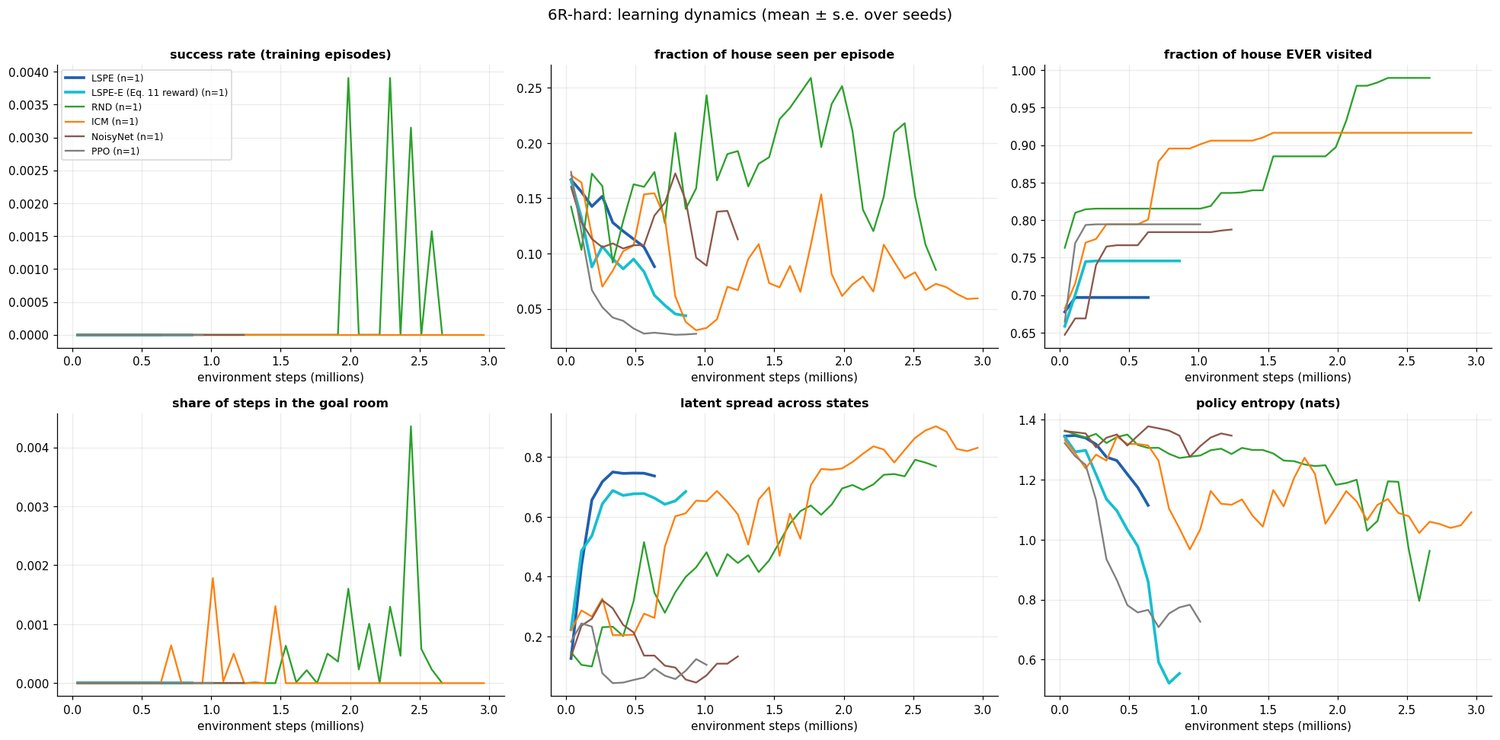

In [107]:
# 6a. 6R-hard: all eight methods (3M steps).
M6 = ["lspe", "lspe_ev", "rnd", "icm", "noisynet", "ppo", "lspe_noerf", "lspe_msd"]
dynamics_figure("6R-hard", M6, 3e6, "p6_dynamics_6R")


In [ ]:
# 6b. 9R-hard-TV: the noisy-TV house. The 4th panel now shows the share of steps spent in the TV room.
MTV = ["lspe", "lspe_ev", "rnd", "icm", "noisynet", "ppo"]
dynamics_figure("9R-hard-TV", MTV, 3e6, "p6_dynamics_TV", extra=("tv_room", "share of steps spent in the noisy-TV room"))


In [ ]:
# 6c. 4R-easy (1M steps): where plain exploration should already suffice.
dynamics_figure("4R-easy", MTV, 1e6, "p6_dynamics_4R")


In [ ]:
# 6d. Final policies (learning off), the paper's Fig. 7 / Table 1 format, plus where each final policy goes (Fig. 2 format).
LV = ["4R-easy", "6R-hard", "9R-hard-TV"]
results_bars(LV, MTV, name="p6_bars_success")
results_bars(LV, MTV, key="eval_cov", ylabel="final-policy coverage per episode (%)", name="p6_bars_coverage")
print("final-policy success rate, % (mean ± std over seeds):")
print(results_table(LV, M6).to_string(index=False))
heatmap_row("6R-hard", M6[:6], name="p6_heatmaps_6R")
heatmap_row("9R-hard-TV", MTV, name="p6_heatmaps_TV")


---
## Part 7: Inside LSPE

Numbers say *whether* an agent explores. The plots in this part show *how*. They load saved checkpoints and look at what the networks compute over the **whole house**, including places the agent rarely visits:

* **the latent map**: every floor cell's latent state, projected to 2-D;
* **the foresight cloud**: D-SPN's sampled futures decoded back onto the map, next to where the policy really ends up K = 8 steps later;
* **the reward field**: `tr Σ` (how unsure D-SPN is) and the direction-averaged bonus `E_u[F]` (Eq. 11) at every cell, at 10%, 25%, 50% and 100% of training;
* **an episode movie**.

To put a predicted latent back on the map, we fit a small **probe** (an MLP from latent to (x, y)) on the target encoder's latents of all floor cells. The probe is only a display tool. The agent never uses it.

In [75]:
%%writefile /kaggle/working/lspe/lspe/inspect_tools.py
"""Tools to look inside a trained agent: encode every cell of a house, probe latents back to (x, y),
sample D-SPN's foresight, and compute the exploration-reward field over the whole map."""
import os, numpy as np, torch, torch.nn as nn
from torch.distributions import Categorical
from .envs import RoomsEnv, geodesic
from .train import make


def load_agent(run_dir, ckpt="ckpt_100.pt", dev="cuda"):
    """Rebuild the agent of a run folder named LEVEL__METHOD[-tag]__sSEED and load one checkpoint."""
    name = run_dir.rstrip("/").split("/")[-1]
    level, method = name.split("__")[0], name.split("__")[1].split("-")[0]
    env, ac, bonus = make(method, level, 1, 0, dev)
    sd = torch.load(f"{run_dir}/{ckpt}", map_location=dev)
    ac.load_state_dict(sd["ac"])
    if bonus is not None and sd["bonus"] is not None:
        bonus.load_state_dict(sd["bonus"]); bonus.stats_init = True
    ac.eval()
    return env, ac, bonus, sd


@torch.no_grad()
def encode_cells(env, ac, n_render=4):
    """Latent z for every floor cell, averaged over `n_render` noisy renders. Returns z (n,d), pos (n,2)."""
    pos = env.floor
    z = torch.stack([ac.enc(env.render(pos[:, 0], pos[:, 1])) for _ in range(n_render)]).mean(0)
    return z, pos


class Probe(nn.Module):
    """MLP z -> (x, y) with standardised inputs. For visualisation only: maps predicted latents onto the map."""
    def __init__(self, z):
        super().__init__()
        self.register_buffer("m", z.mean(0)); self.register_buffer("s", z.std(0) + 1e-6)
        self.net = nn.Sequential(nn.Linear(z.shape[1], 256), nn.ReLU(), nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 2))

    def forward(self, z):
        return self.net((z - self.m) / self.s)


def fit_probe(z, pos, steps=4000, seed=0):
    torch.manual_seed(seed)
    net = Probe(z).to(z.device)
    opt = torch.optim.Adam(net.parameters(), lr=2e-3)
    y = pos.float()
    for i in range(steps):
        l = (net(z) - y).pow(2).sum(-1).mean()
        opt.zero_grad(); l.backward(); opt.step()
    with torch.no_grad():
        err = (net(z) - y).norm(dim=-1).mean().item()
    return net, err


@torch.no_grad()
def foresight(bonus, z, M=64, steps=10):
    """M sampled future latents per row of z, converted back to raw latent units (M, n, d)."""
    s = bonus.predict(z, M=M, steps=steps)
    return s * bonus.sd + bonus.mu


@torch.no_grad()
def true_futures(env_level, ac, start, K=8, n=256, dev="cuda"):
    """Where the policy actually is K steps after starting at cell `start` (n rollouts)."""
    e = RoomsEnv(env_level, n, dev, seed=7)
    e.x[:] = start[0]; e.y[:] = start[1]; e.t[:] = 0
    alive = torch.ones(n, dtype=torch.bool, device=dev)
    for _ in range(K):
        a = Categorical(logits=ac(e.render())[1]).sample()
        _, _, d, _ = e.step(a)
        alive &= ~d
    return e.pos()[alive].cpu().numpy()


@torch.no_grad()
def erf_field(env, ac, bonus, n_render=2):
    """Per floor cell: tr(Sigma) of D-SPN's foresight and the direction-averaged exploration reward
    E_u[F] (Theorem 2, Eq. 11), averaged over the moves available from that cell."""
    pos = env.floor
    z, _ = encode_cells(env, ac, n_render)
    samples = bonus.predict(z, M=32)                                   # (M, n, d), standardised units
    zhat = samples.mean(0)
    cen = samples - zhat
    Sig = torch.einsum("mnd,mne->nde", cen, cen) / (samples.shape[0] - 1)
    h = bonus.h(z, zhat)
    idx = -torch.ones(env.H, env.W, dtype=torch.long, device=pos.device)
    idx[pos[:, 1], pos[:, 0]] = torch.arange(len(pos), device=pos.device)
    d = h.shape[1]; tot = torch.zeros(len(pos), device=pos.device); cnt = torch.zeros_like(tot)
    for dx, dy in ((0, -1), (0, 1), (-1, 0), (1, 0)):
        nb = idx[pos[:, 1] + dy, pos[:, 0] + dx]
        ok = nb >= 0
        delta = h[ok] - h[nb[ok]]
        S = Sig[ok]
        val = ((delta * delta).sum(-1) * S.diagonal(dim1=1, dim2=2).sum(-1)
               + 2 * torch.einsum("nd,nde,ne->n", delta, S, delta)) / (d * (d + 2))
        tot[ok] += val; cnt[ok] += 1
    return dict(trSigma=_to_grid(env, Sig.diagonal(dim1=1, dim2=2).sum(-1)), EF=_to_grid(env, tot / cnt.clamp(min=1)))


def _to_grid(env, v):
    g = np.full((env.H, env.W), np.nan)
    p = env.floor.cpu().numpy()
    g[p[:, 1], p[:, 0]] = v.detach().cpu().numpy() if torch.is_tensor(v) else v
    return g


Overwriting /kaggle/working/lspe/lspe/inspect_tools.py


In [110]:
purge()
from lspe.inspect_tools import load_agent, encode_cells, fit_probe, foresight, true_futures, erf_field, _to_grid
from lspe.envs import geodesic, ROOM_COLORS
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

def cell_rooms(env):
    p = env.floor.cpu().numpy(); k = env.layout["room"][p[:, 1], p[:, 0]]
    return np.array([ROOM_COLORS[kk % 9] if kk >= 0 else (0.55, 0.55, 0.55) for kk in k]), k

def shortest_path(L, start, goal):
    D = geodesic(L, goal); path = [start]; x, y = start
    while (x, y) != tuple(goal):
        x, y = min(((x + dx, y + dy) for dx, dy in ((0, -1), (0, 1), (-1, 0), (1, 0))
                    if D[y + dy, x + dx] >= 0), key=lambda c: D[c[1], c[0]])
        path.append((x, y))
    return path

def linear_r2(z, pos):
    """R² of the best LINEAR map from latent z to (x, y): how 'map-like' the representation is."""
    X = torch.cat([z, torch.ones(len(z), 1, device=z.device)], 1).double(); Y = pos.double()
    W = torch.linalg.pinv(X) @ Y
    return float(1 - ((X @ W - Y) ** 2).sum() / ((Y - Y.mean(0)) ** 2).sum())

def map_bg(ax, env, alpha=0.45):
    ax.imshow(env.map_rgb, extent=(0, env.W, env.H, 0), alpha=alpha); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    gx, gy = env.layout["goal"]; ax.plot(gx + .5, gy + .5, "*", ms=14, mfc="gold", mec="k", zorder=5)
print("inspection helpers ready")


inspection helpers ready


In [48]:
def latent_panel(run_dir, ckpt="ckpt_100.pt", axes=None, title=""):
    """PCA of the policy encoder's latent for every floor cell, coloured by room and by distance-to-goal."""
    env, ac, bonus, sd = load_agent(run_dir, ckpt)
    z, pos = encode_cells(env, ac)
    cols, rooms = cell_rooms(env)
    D = geodesic(env.layout, env.layout["goal"]); p = pos.cpu().numpy(); dg = D[p[:, 1], p[:, 0]]
    Z2 = PCA(2).fit_transform(z.cpu().numpy())
    r2 = linear_r2(z, pos)
    ax = axes[0]; ax.scatter(Z2[:, 0], Z2[:, 1], c=cols, s=16, edgecolor="k", lw=0.2); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{title}\nlatent PCA, coloured by room", fontsize=9.5)
    ax = axes[1]; sc = ax.scatter(Z2[:, 0], Z2[:, 1], c=dg, cmap="viridis_r", s=16); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"coloured by steps-to-goal\nlinear (x,y) decodability R² = {r2:.2f}", fontsize=9.5)
    return dict(r2=r2, z=z, pos=pos, env=env, ac=ac, bonus=bonus)
print("ok")


ok


In [97]:
@torch.no_grad()
def encode_at(net, env, xy, n=4):
    x = torch.tensor([c[0] for c in xy], device=DEV); y = torch.tensor([c[1] for c in xy], device=DEV)
    return torch.stack([net(env.render(x, y)) for _ in range(n)]).mean(0)

def anchors(L):
    path = shortest_path(L, L["start_cells"][len(L["start_cells"]) // 2], L["goal"])
    doors = [i for i, c in enumerate(path) if L["room"][c[1], c[0]] == -2]
    idx = [0, doors[0], doors[len(doors) // 2] if len(doors) > 2 else len(path) // 2, len(path) - 4]
    return [path[i] for i in idx], ["the start room", "the first doorway", "a mid-house doorway", "beside the goal"]

def foresight_figure(run_dir, ckpt="ckpt_100.pt", M=160, name="p7_foresight"):
    env, ac, bonus, sd = load_agent(run_dir, ckpt)
    L, pos = env.layout, env.floor
    with torch.no_grad():
        zt = torch.stack([bonus.enc_t(env.render(pos[:, 0], pos[:, 1])) for _ in range(4)]).mean(0)
    probe, perr = fit_probe(zt, pos)                           # decoder latent -> (x, y), for display only
    pts, names = anchors(L)
    fig, axes = plt.subplots(1, 4, figsize=(18, 5.2)); rng = np.random.default_rng(0); stats = []
    for ax, (cx, cy), nm in zip(axes, pts, names):
        z0 = encode_at(ac.enc, env, [(cx, cy)])
        with torch.no_grad():
            pp = probe(foresight(bonus, z0, M=M)[:, 0]).cpu().numpy()
        tf = true_futures(env.level, ac, (cx, cy), K=bonus.K)
        map_bg(ax, env)
        ax.scatter(tf[:, 0] + 0.5 + rng.uniform(-.35, .35, len(tf)), tf[:, 1] + 0.5 + rng.uniform(-.35, .35, len(tf)),
                   s=8, c="#2ca02c", alpha=0.45, label=f"where the policy really is {bonus.K} steps later")
        ax.scatter(pp[:, 0] + 0.5, pp[:, 1] + 0.5, s=9, c="#1f5fae", alpha=0.55, label=f"D-SPN foresight ({M} samples, decoded)")
        ax.plot(cx + .5, cy + .5, "o", ms=12, mfc="white", mec="k", mew=2, zorder=6)
        ax.set_xlim(cx - 8, cx + 9); ax.set_ylim(cy + 9, cy - 8)
        cd = np.linalg.norm(pp.mean(0) - tf.mean(0)); sr = pp.std(0).mean() / (tf.std(0).mean() + 1e-6)
        stats.append((nm, round(float(cd), 2), round(float(sr), 2)))
        ax.set_title(f"from {nm}\ncentroid gap {cd:.1f} cells, spread ratio {sr:.2f}", fontsize=10)
    axes[0].legend(loc="lower left", fontsize=7.5, framealpha=0.9)
    fig.suptitle(f"D-SPN's foresight vs reality ({os.path.basename(run_dir)}, {sd['steps'] / 1e6:.1f}M steps). "
                 f"Decoder error on real states: {perr:.2f} cells", fontsize=12, y=1.02)
    show(fig, name)
    return stats

def erf_over_training(run_dir, fracs=(10, 25, 50, 100), name="p7_erf_over_training"):
    fig, axes = plt.subplots(3, len(fracs), figsize=(4.4 * len(fracs), 11), squeeze=False)
    for c, f in enumerate(fracs):
        env, ac, bonus, sd = load_agent(run_dir, f"ckpt_{f:03d}.pt")
        fld = erf_field(env, ac, bonus)
        vis = np.load(f"{run_dir}/visits_{f:03d}.npy").astype(float); vis[env.layout["wall"]] = np.nan
        for r, (arr, cmap, lab) in enumerate([(np.log10(vis + 1), "magma", "log10 visits so far"),
                                              (fld["trSigma"], "cividis", "tr Σ: foresight uncertainty"),
                                              (fld["EF"] / sd["fscale"], "inferno", "E_u[F] / mean bonus (Eq. 11)")]):
            ax = axes[r, c]; map_bg(ax, env, 0.25)
            im = ax.imshow(arr, cmap=cmap, extent=(0, env.W, env.H, 0), alpha=0.9)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
            if c == 0:
                ax.set_ylabel(lab, fontsize=10)
            if r == 0:
                ax.set_title(f"{sd['steps'] / 1e6:.2f}M steps ({f}%)", fontsize=11)
    fig.suptitle(f"How LSPE's exploration reward moves as the agent learns ({os.path.basename(run_dir)})", fontsize=13, y=1.0)
    fig.tight_layout(); show(fig, name)

def distance_field(run_dir, ref=None, ckpt="ckpt_100.pt"):
    """Latent distance from one reference cell to every cell, vs the true shortest-path distance."""
    env, ac, bonus, sd = load_agent(run_dir, ckpt)
    z, pos = encode_cells(env, ac)
    if bonus is not None and hasattr(bonus, "h"):
        emb = bonus.h(z, bonus.predict(z).mean(0)).detach()
    else:
        emb = z
    ref = ref or env.layout["start_cells"][len(env.layout["start_cells"]) // 2]
    p = pos.cpu().numpy(); i0 = int(np.where((p[:, 0] == ref[0]) & (p[:, 1] == ref[1]))[0][0])
    dl = (emb - emb[i0]).abs().mean(-1).cpu().numpy()
    G = geodesic(env.layout, ref); dg = G[p[:, 1], p[:, 0]]
    return env, _to_grid(env, dl), dl, dg, spearmanr(dl, dg).correlation, ref
print("ok")


ok


In [70]:
from lspe.agents import unit_dirs
from torch.distributions import Categorical

def episode_movie(run_dir, ckpt="ckpt_100.pt", name="p7_episode", M=48, seed=3, every=2, max_kb=420):
    """One episode of the trained LSPE agent: its view, its trail, D-SPN's decoded foresight cloud, and the
    exploration reward F it earns at each step. Saved as a GIF; a compact version is shown inline."""
    env, ac, bonus, sd = load_agent(run_dir, ckpt)
    pos = env.floor
    with torch.no_grad():
        zt = torch.stack([bonus.enc_t(env.render(pos[:, 0], pos[:, 1])) for _ in range(4)]).mean(0)
    probe, perr = fit_probe(zt, pos)
    torch.manual_seed(seed)
    e = RoomsEnv(env.level, 1, DEV, seed=seed)
    obs = e.render(); u = unit_dirs(1, 32, DEV); rec = []
    for t in range(e.max_steps):
        with torch.no_grad():
            z, logits, _ = ac(obs)
            s = bonus.predict(z, M=M)                                  # (M,1,d) standardised futures
            h = bonus.h(z, s.mean(0))
            cloud = probe(s[:, 0] * bonus.sd + bonus.mu).cpu().numpy()
            unc = (s[:, 0] @ u[0]).var().item()
        p = tuple(e.pos()[0].tolist()); o = obs[0].permute(1, 2, 0).cpu().numpy()
        a = Categorical(logits=logits).sample()
        obs, r, d, _ = e.step(a)
        with torch.no_grad():
            z1 = ac.enc(obs); h1 = bonus.h(z1, bonus.predict(z1, M=M).mean(0))
        F = float(((h - h1) @ u[0]) ** 2 * unc) if not d.item() else 0.0
        rec.append(dict(p=p, o=o, cloud=cloud, F=F, done=bool(d.item()), win=bool(r.item() > 0)))
        if d.item():
            break
    Fs = np.array([x["F"] for x in rec])
    frames = []
    for t in range(0, len(rec), every):
        x = rec[t]
        fig = plt.figure(figsize=(10, 4.2), dpi=72)
        ax = fig.add_axes([0.01, 0.04, 0.42, 0.84]); map_bg(ax, env, 0.6)
        tr = np.array([q["p"] for q in rec[:t + 1]]) + 0.5
        ax.plot(tr[:, 0], tr[:, 1], "-", c="white", lw=2, alpha=0.9)
        ax.scatter(x["cloud"][:, 0] + 0.5, x["cloud"][:, 1] + 0.5, s=10, c="#1f5fae", alpha=0.6)
        ax.plot(x["p"][0] + .5, x["p"][1] + .5, "o", ms=9, mfc="#d62728", mec="k")
        ax.set_title(f"step {t}: trail (white), D-SPN foresight {bonus.K} steps ahead (blue)", fontsize=9)
        ax2 = fig.add_axes([0.45, 0.22, 0.2, 0.6]); ax2.imshow(x["o"]); ax2.axis("off"); ax2.set_title("what the agent sees", fontsize=9)
        ax3 = fig.add_axes([0.71, 0.18, 0.27, 0.64])
        ax3.plot(Fs[:t + 1], c="#bf616a", lw=1.2); ax3.set_xlim(0, len(rec)); ax3.set_ylim(0, np.percentile(Fs, 99) * 1.1 + 1e-9)
        ax3.set_title("exploration reward F per step", fontsize=9); ax3.set_xlabel("step", fontsize=8); ax3.tick_params(labelsize=7)
        buf = io.BytesIO(); fig.savefig(buf, format="png"); plt.close(fig)
        frames.append(PILImage.open(buf).convert("RGB"))
    frames += [frames[-1]] * 6
    def gif_bytes(fr, scale):
        fr = [f.resize((int(f.width * scale), int(f.height * scale)), PILImage.LANCZOS).quantize(64) for f in fr]
        out = io.BytesIO(); fr[0].save(out, format="GIF", save_all=True, append_images=fr[1:], duration=110, loop=0, optimize=True)
        return out.getvalue()
    open(f"{ROOT}/figs/{name}.gif", "wb").write(gif_bytes(frames, 1.0))
    fr, scale = frames, 0.8
    while True:
        g = gif_bytes(fr, scale)
        if len(g) < max_kb * 1024 or len(fr) < 12:
            break
        fr, scale = fr[::2], scale * 0.9
    display(IPImage(data=g, format="gif"))
    print(f"{len(rec)} steps, reached goal: {rec[-1]['win']}; full GIF saved to figs/{name}.gif; inline copy {len(g) / 1024:.0f} KB")
    return rec
print("ok")


ok


In [ ]:
# 7a. The latent map: what each method's encoder makes of the 287 floor cells of 6R-hard (final checkpoints).
cmp = [m for m in ["ppo", "rnd", "lspe", "lspe_ev"] if runs("6R-hard", m) and os.path.exists(f"{runs('6R-hard', m)[0]}/ckpt_100.pt")]
fig, axes = plt.subplots(2, len(cmp), figsize=(4.6 * len(cmp), 9), squeeze=False)
r2s = {}
for c, m in enumerate(cmp):
    res = latent_panel(runs("6R-hard", m)[0], "ckpt_100.pt", axes=axes[:, c], title=STYLE[m][0])
    r2s[STYLE[m][0]] = round(res["r2"], 3)
fig.suptitle("6R-hard: every floor cell's latent state, projected to 2-D (PCA). Left column of each pair: room colours; below: steps to the goal",
             fontsize=12, y=1.0)
fig.tight_layout(); show(fig, "p7_latent_maps")
print("linear (x,y) decodability R²:", r2s)


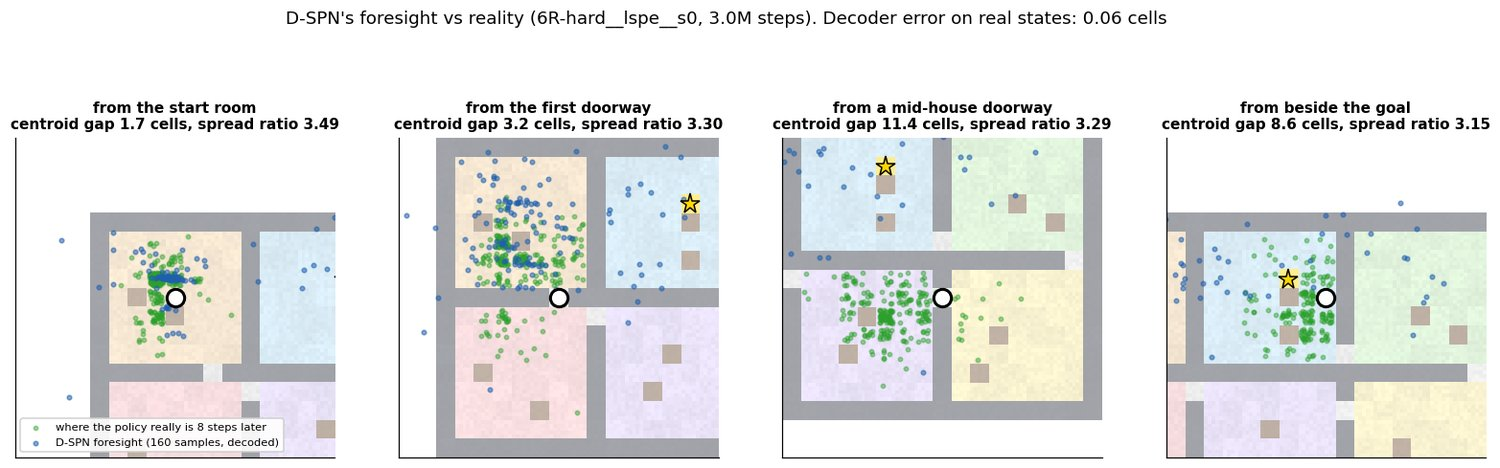

               from  centroid gap (cells)  spread ratio (pred/true)
     the start room                  1.70                      3.49
  the first doorway                  3.17                      3.30
a mid-house doorway                 11.42                      3.29
    beside the goal                  8.65                      3.15


In [121]:
# 7b. The foresight cloud of the final LSPE agent on 6R-hard.
fs_stats = foresight_figure(runs("6R-hard", "lspe")[0], "ckpt_100.pt", name="p7_foresight")
print(pd.DataFrame(fs_stats, columns=["from", "centroid gap (cells)", "spread ratio (pred/true)"]).to_string(index=False))


**Reading the foresight cloud.** Green dots are where the trained policy really is 8 steps after leaving the white circle, over 256 rollouts. Blue dots are 160 futures sampled from D-SPN, decoded onto the map by the probe.
* **Where the agent has lived (the start room), foresight is good.** The predicted cloud sits on top of the real one (a gap of about 2 cells).
* **Where it has rarely or never been (a mid-house doorway, beside the goal), foresight is wrong by 9 to 11 cells.** The samples scatter to places the policy does not go.
* **The spread is the same in both places.** The ratio of predicted to real spread is about 3.3 everywhere. The model is *confidently wrong* where it has no data. Its sample spread is not wider there, and that spread is exactly the `Σ_t` that the exploration reward multiplies by.

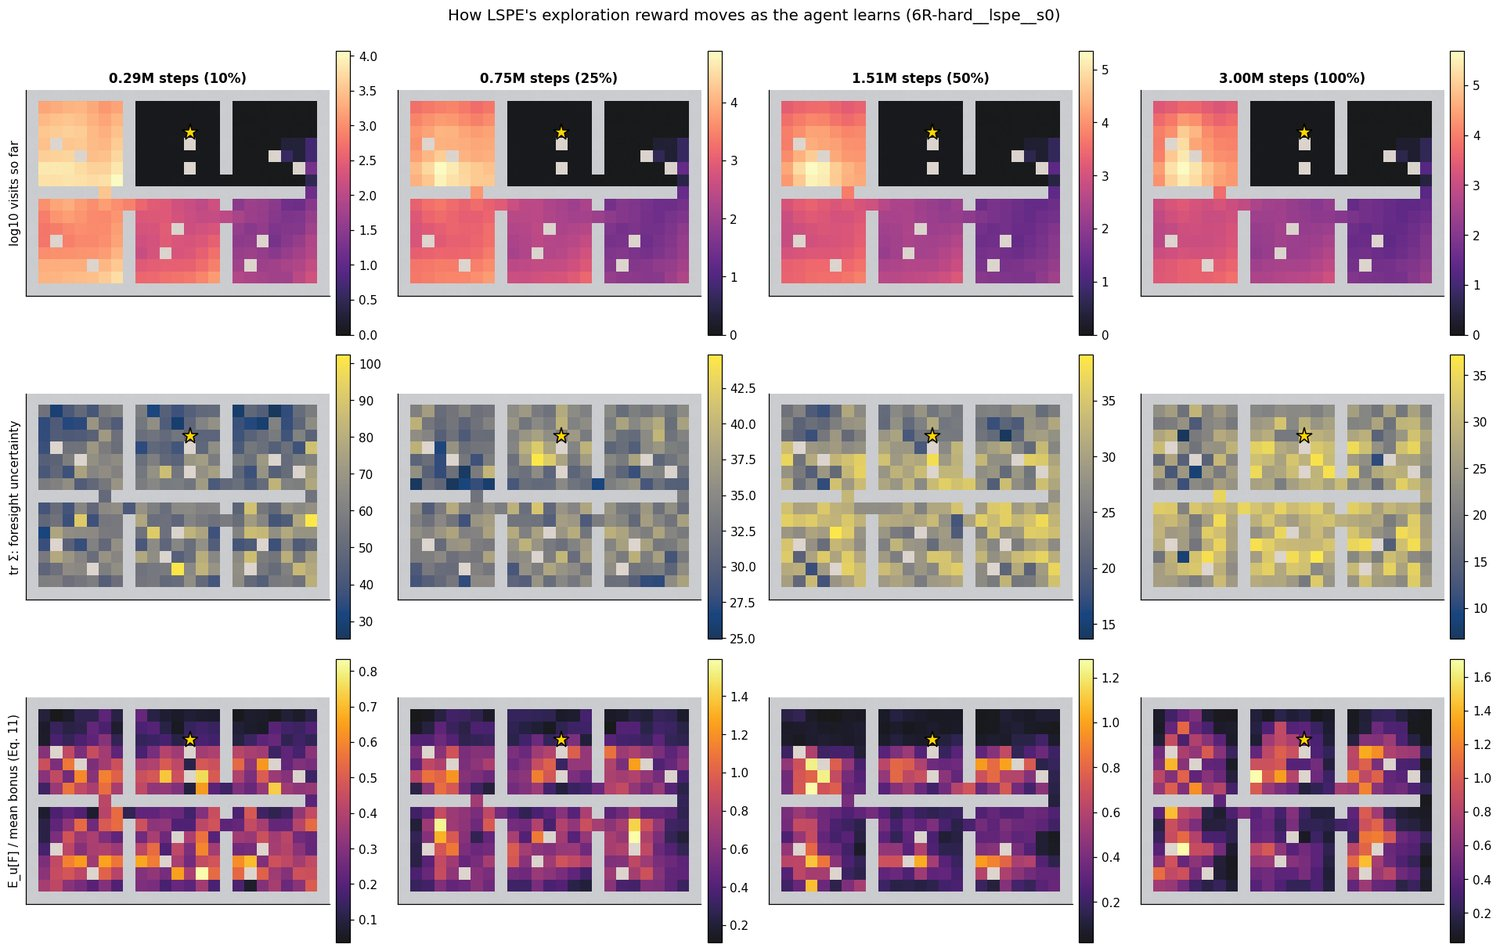

In [122]:
# 7c. The exploration-reward field over training (LSPE, 6R-hard, seed 0).
erf_over_training(runs("6R-hard", "lspe")[0], name="p7_erf_over_training")


**Reading the reward field.** Each column is a checkpoint. Top row: where the agent has been so far. Middle: D-SPN's uncertainty `tr Σ` at every cell. Bottom: the direction-averaged exploration reward `E_u[F]` for stepping out of that cell (Eq. 11, in units of the run's average bonus).
* The agent spends 3M steps in the start room and the bottom row of rooms. **It never enters the top-right room or the goal room** (black in the top row).
* From 50% of training on, `tr Σ` is **higher in the rooms the agent lives in** (yellow, bottom row) than in the rooms it has never seen (darker, top row). D-SPN has learned the real spread of futures where it has data, which is the policy's own randomness at doorways. Where it has no data, it produces a *narrower* cloud.
* So the quantity the paper calls uncertainty behaves here like "how many different things usually happen from this state", which is aleatoric. It is not "how little I know about this state", which is epistemic. An exploration bonus built on it cannot pull the agent into unseen rooms. Part 8 measures this directly and tests a fix.

In [ ]:
# 7d. Does latent distance track real distance? Distance from the start cell to every cell, in each method's latent
#     space (LSPE: the temporal-aware embedding h that the bisimulation loss shapes), next to the true path distance.
cmp = [m for m in ["ppo", "rnd", "lspe_msd", "lspe"] if runs("6R-hard", m) and os.path.exists(f"{runs('6R-hard', m)[0]}/ckpt_100.pt")]
fig, axes = plt.subplots(1, len(cmp) + 1, figsize=(4.4 * (len(cmp) + 1), 4.2))
for ax, m in zip(axes[1:], cmp):
    env, grid_, dl, dg, rho, ref = distance_field(runs("6R-hard", m)[0])
    map_bg(ax, env, 0.3); im = ax.imshow(grid_, cmap="viridis", extent=(0, env.W, env.H, 0), alpha=0.9)
    ax.plot(ref[0] + .5, ref[1] + .5, "o", ms=10, mfc="white", mec="k")
    ax.set_title(f"{STYLE[m][0]}: latent distance\nSpearman ρ vs path distance = {rho:.2f}", fontsize=10)
G = geodesic(env.layout, ref).astype(float); G[env.layout["wall"]] = np.nan
map_bg(axes[0], env, 0.3); axes[0].imshow(G, cmap="viridis", extent=(0, env.W, env.H, 0), alpha=0.9)
axes[0].plot(ref[0] + .5, ref[1] + .5, "o", ms=10, mfc="white", mec="k"); axes[0].set_title("ground truth:\nshortest-path distance", fontsize=10)
fig.suptitle("6R-hard: how far is every cell from the start, according to each encoder? (bright = far)", y=1.05)
show(fig, "p7_distance_fields")


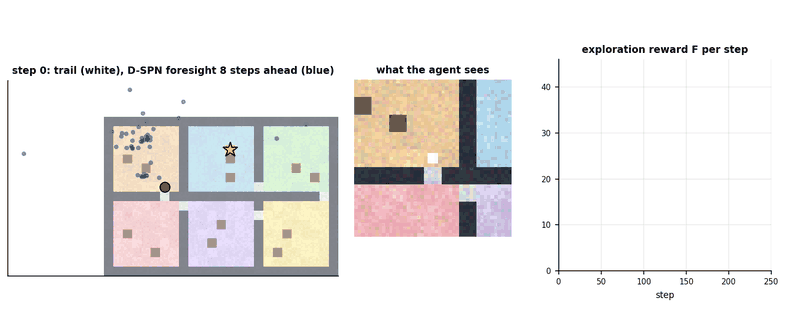

250 steps, reached goal: False; full GIF saved to figs/p7_episode_6R.gif; inline copy 388 KB


In [123]:
# 7e. One episode of the final LSPE agent: its view, its trail, D-SPN's foresight cloud and the reward it earns.
_ = episode_movie(runs("6R-hard", "lspe")[0], "ckpt_100.pt", name="p7_episode_6R")


---
## Part 8: Why does it behave this way? Ablations and bonus forensics

Three questions, each answered by a measurement rather than a story:

1. **What does each bonus actually reward?** We feed the *same* random-walk transitions, started uniformly over the house, to every trained bonus and ask two things. Does it pay more for a real move than for bumping into a wall (`move_vs_bump`)? Does it pay more for stepping into cells that run rarely visited (`novelty_rho`, the Spearman correlation between the bonus and minus log visit count)? A novelty bonus should score clearly above 0 on the second.
2. **What did each encoder learn?** Measured over **every** floor cell: spread, effective rank, how linearly (x, y) can be read out, and whether latent distance tracks true path distance.
3. **The paper's ablations.** `LSPE w/o ERF` (no exploration reward) and `LSPE w MSD` (plain one-step bisimulation instead of the temporal-aware one), plus our `LSPE-E`.

In [111]:
@torch.no_grad()
def bonus_diagnostic(run_dir, ckpt="ckpt_100.pt", T=64, B=256, seed=0):
    """Feed the SAME random-walk transitions (started uniformly over the house) to a trained bonus and ask:
       1. does it pay more for a real move than for bumping into a wall (s' = s up to pixel noise)?
       2. does it pay more for stepping into rarely-visited cells (by that run's own lifetime visit counts)?"""
    env0, ac, bonus, sd = load_agent(run_dir, ckpt)
    frac = int(ckpt[5:8]); visits = np.load(f"{run_dir}/visits_{frac:03d}.npy").astype(float)
    torch.manual_seed(seed)
    e = RoomsEnv(env0.level, B, DEV, seed=seed)
    k = torch.randint(len(e.floor), (B,), device=DEV); e.x[:] = e.floor[k, 0]; e.y[:] = e.floor[k, 1]
    buf = dict(obs=torch.zeros(T + 1, B, 3, e.V, e.V, dtype=torch.uint8, device=DEV), act=torch.zeros(T, B, dtype=torch.long, device=DEV),
               done=torch.zeros(T, B, device=DEV), u=unit_dirs(T * B, 32, DEV).view(T, B, 32))
    pos = torch.zeros(T + 1, B, 2, dtype=torch.long, device=DEV); obs = e.render()
    for t in range(T):
        buf["obs"][t], pos[t] = obs, e.pos()
        a = torch.randint(0, 4, (B,), device=DEV); buf["act"][t] = a
        obs, _, d, _ = e.step(a); buf["done"][t] = d.float()
    buf["obs"][T], pos[T] = obs, e.pos()
    F = bonus.rewards(buf).cpu().numpy()
    p = pos.cpu().numpy(); valid = buf["done"].cpu().numpy() == 0
    moved = (p[1:] != p[:-1]).any(-1) & valid
    stay = ~(p[1:] != p[:-1]).any(-1) & valid
    vnext = visits[p[1:, :, 1], p[1:, :, 0]]
    rho = spearmanr(F[moved], -np.log1p(vnext[moved])).correlation
    return dict(move_vs_bump=F[moved].mean() / (F[stay].mean() + 1e-12), novelty_rho=rho,
                F_bump_share=F[stay].mean() / (F[valid].mean() + 1e-12))

print(pd.DataFrame({os.path.basename(d) + " " + c: bonus_diagnostic(d, c) for d, c in
                    [(f"{ROOT}/runs/6R-hard__icm__s0", "ckpt_100.pt"), (f"{ROOT}/runs/6R-hard__lspe__s0", "ckpt_010.pt"),
                     (f"{ROOT}/runs/6R-hard__lspe_ev__s0", "ckpt_025.pt")]}).T.to_string(float_format=lambda x: f"{x:.3f}"))


                                  move_vs_bump  novelty_rho  F_bump_share
6R-hard__icm__s0 ckpt_100.pt             1.354        0.166         0.778
6R-hard__lspe__s0 ckpt_010.pt            2.324       -0.047         0.484
6R-hard__lspe_ev__s0 ckpt_025.pt         1.456       -0.154         0.731


In [94]:
def representation_report(level, methods, ckpt="ckpt_100.pt"):
    """For each method's final encoder, measured over EVERY floor cell (not just where the policy goes):
    spread of latents, how linearly (x,y) can be read out, and how well latent distance tracks true path distance."""
    rows = []
    for m in methods:
        for d in runs(level, m):
            if not os.path.exists(f"{d}/{ckpt}"):
                continue
            env, ac, bonus, sd = load_agent(d, ckpt)
            z, pos = encode_cells(env, ac)
            p = pos.cpu().numpy()
            ref = env.layout["start_cells"][len(env.layout["start_cells"]) // 2]
            i0 = int(np.where((p[:, 0] == ref[0]) & (p[:, 1] == ref[1]))[0][0])
            dz = (z - z[i0]).norm(dim=-1).cpu().numpy(); dg = geodesic(env.layout, ref)[p[:, 1], p[:, 0]]
            rows.append(dict(method=STYLE[m][0], seed=os.path.basename(d)[-2:], spread=float(z.std(0).mean()),
                             erank=erank_cells(z), xy_R2=linear_r2(z, pos), dist_vs_path_rho=spearmanr(dz, dg).correlation))
    return pd.DataFrame(rows)

def erank_cells(z):
    s = torch.linalg.svdvals(z - z.mean(0)); p = s / s.sum()
    return float(torch.exp(-(p * torch.log(p + 1e-12)).sum()))
print("ok")


ok


In [ ]:
# 8a. Bonus forensics on every finished 6R-hard and 9R-hard-TV run with a bonus (final checkpoints).
rows = []
for lv in ["6R-hard", "9R-hard-TV"]:
    for m in ["lspe", "lspe_ev", "lspe_msd", "rnd", "icm"]:
        for d in runs(lv, m):
            if os.path.exists(f"{d}/ckpt_100.pt"):
                r = bonus_diagnostic(d, "ckpt_100.pt"); r.update(level=lv, method=STYLE[m][0], seed=d[-2:]); rows.append(r)
forensics = pd.DataFrame(rows)[["level", "method", "seed", "move_vs_bump", "novelty_rho", "F_bump_share"]]
print(forensics.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
fig, ax = plt.subplots(figsize=(8, 4.5))
for m, g in forensics.groupby("method"):
    col = [v[1] for v in STYLE.values() if v[0] == m][0]
    ax.scatter(g.move_vs_bump, g.novelty_rho, s=80, color=col, label=m, edgecolor="k", zorder=3)
ax.axhline(0, c="k", lw=0.8); ax.axvline(1, c="k", lw=0.8)
ax.set_xlabel("pays for moving vs bumping a wall (ratio; 1 = no difference)")
ax.set_ylabel("tracks novelty (Spearman ρ with rarity)")
ax.set_title("What does each trained bonus reward? (same random-walk transitions for all)"); ax.legend(fontsize=8)
show(fig, "p8_bonus_forensics")


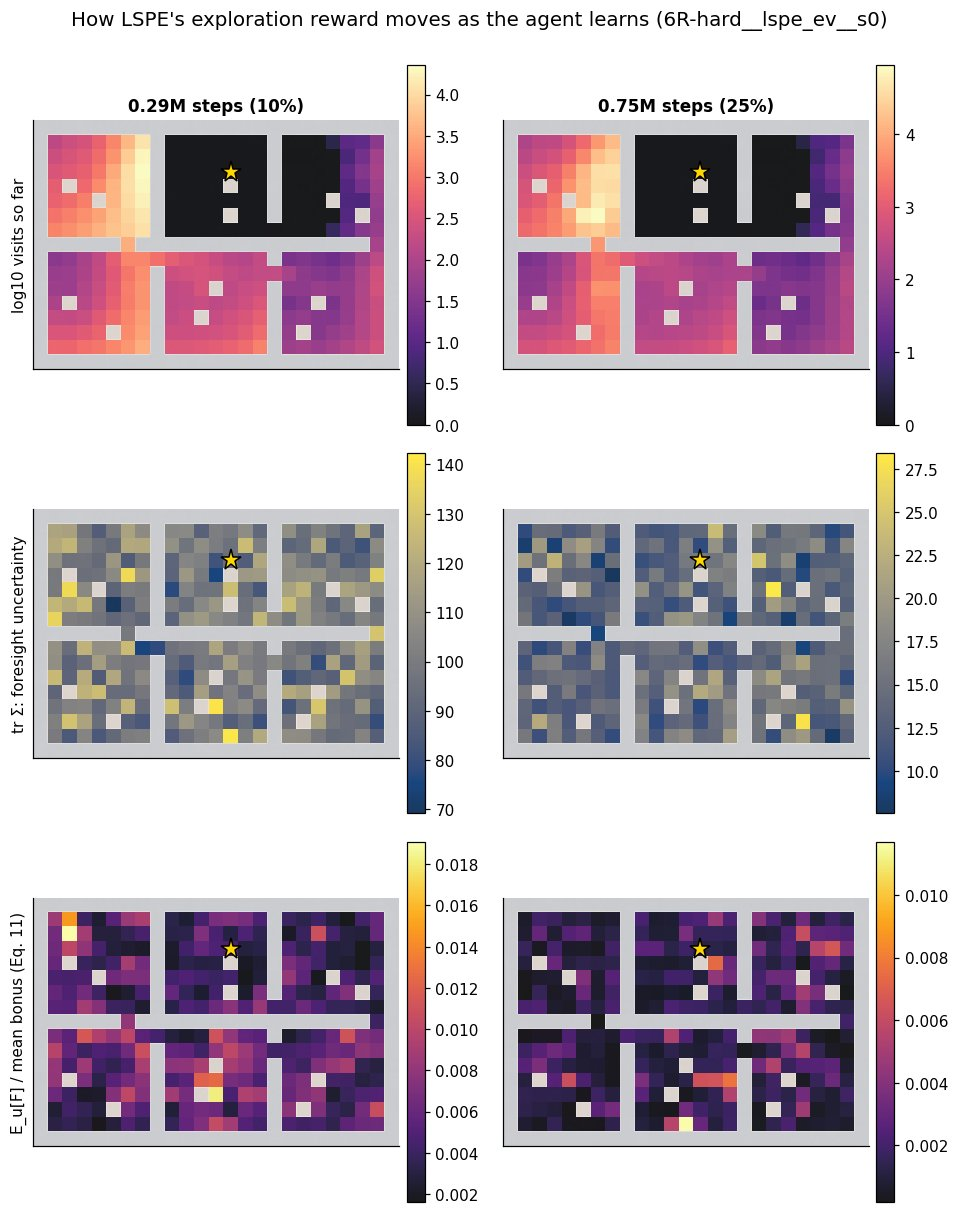

In [108]:
# 8a-bis. The property LSPE's bonus relies on: is D-SPN MORE uncertain where the agent has rarely been?
# Per checkpoint: Spearman correlation, over all floor cells, of tr Σ (and of E_u[F]) with rarity = -log(1 + visits so far).
rows = []
for m in ["lspe", "lspe_ev"]:
    for d in runs("6R-hard", m):
        for f in (10, 25, 50, 100):
            if not os.path.exists(f"{d}/ckpt_{f:03d}.pt"):
                continue
            env, ac, bonus, sd = load_agent(d, f"ckpt_{f:03d}.pt")
            fld = erf_field(env, ac, bonus)
            vis = np.load(f"{d}/visits_{f:03d}.npy").astype(float); ok = ~env.layout["wall"]
            rows.append(dict(method=STYLE[m][0], seed=d[-2:], pct_of_training=f, unvisited_cells=int((vis[ok] == 0).sum()),
                             rho_trSigma_vs_rarity=spearmanr(fld["trSigma"][ok], -np.log1p(vis[ok])).correlation,
                             rho_EF_vs_rarity=spearmanr(fld["EF"][ok], -np.log1p(vis[ok])).correlation))
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x: f"{x:.3f}"))
erf_over_training(runs("6R-hard", "lspe_ev")[0], name="p8_lspe_ev_field")


In [ ]:
# 8b. What did each encoder learn? (6R-hard, final checkpoints, measured over all 287 floor cells)
rep = representation_report("6R-hard", ["ppo", "noisynet", "rnd", "icm", "lspe", "lspe_ev", "lspe_noerf", "lspe_msd"])
print(rep.groupby("method", sort=False)[["spread", "erank", "xy_R2", "dist_vs_path_rho"]].mean().to_string(float_format=lambda x: f"{x:.3f}"))


In [ ]:
# 8c. The ablations on 6R-hard, side by side with full LSPE and LSPE-E.
MA = ["lspe", "lspe_ev", "lspe_noerf", "lspe_msd", "ppo"]
fig, axes = plt.subplots(1, 4, figsize=(19, 4.2))
for ax, (key, t) in zip(axes, [("ep_cov", "fraction of house seen per episode"), ("glob_cov", "fraction of house EVER visited"),
                               ("ent", "policy entropy"), ("bisim_dist", "mean bisimulation distance d(h_i, h_j)")]):
    plot_metric(ax, "6R-hard", MA, key, 3e6); ax.set_title(t, fontsize=10.5); ax.set_ylabel("")
axes[0].legend(fontsize=8)
fig.suptitle("6R-hard ablations: remove the exploration reward (w/o ERF), or the temporal-aware metric (w MSD)", y=1.03)
show(fig, "p8_ablations")


### 8d. A targeted experiment of our own: LSPE-Ens

The forensics above point at one specific ingredient. LSPE's uncertainty `Σ_t` is the **spread of samples from one diffusion model**. A diffusion model is trained to reproduce the *true* spread of futures, and in this house much of that spread comes from the policy's own randomness: from a doorway, you might go left or right. That is **aleatoric** uncertainty, and it never shrinks no matter how often you visit. Meanwhile, in a room the agent has never entered, an untrained conditional model has no particular reason to produce a *wider* cloud of samples. So nothing in `Σ_t` says "I have not been here".

The classic fix for this confusion is an **ensemble** (Pathak et al. 2019, "exploration via disagreement"). Train several models independently on the same data. Where they have data, they agree. Where they have none, they disagree. **LSPE-Ens** keeps everything from LSPE-E and changes only one thing: `Σ_t` is the covariance of the **mean predictions of 4 independently trained D-SPN heads**, not the covariance of one head's samples. If our diagnosis is right, LSPE-Ens should track novelty in the forensics test and explore more of the house.

In [117]:
%%writefile /kaggle/working/lspe/lspe/agents_ens.py
"""LSPE-Ens: our targeted variant to test the diagnosis of Part 8.

Identical to LSPE-E (direction-averaged reward, Eq. 11) except for WHERE the uncertainty Sigma comes from.
LSPE: Sigma = spread of M samples from ONE diffusion model. That spread contains the policy's own, irreducible
      randomness (aleatoric), which never shrinks with experience.
Ens:  Sigma = disagreement between the MEAN predictions of 4 independently initialised and independently trained
      D-SPN heads (epistemic). Heads agree where they have data and disagree where they do not.
"""
import torch, torch.nn as nn
from .agents import LSPE, chunked
from .nets import LatentDDPM


class LSPEEns(LSPE):
    def __init__(self, enc, n_heads=4, M_head=4, head_width=128, **kw):
        super().__init__(enc, erf="expect", **kw)
        self.psi = nn.ModuleList([LatentDDPM(self.d, self.d, h=head_width) for _ in range(n_heads)])
        self.opt_psi = torch.optim.Adam(self.psi.parameters(), lr=5e-4)
        self.M_head = M_head

    @torch.no_grad()
    def head_means(self, z, M=None, steps=None):
        """(H, n, d): each head's mean predicted future (standardised units)."""
        M = M or self.M_head
        return torch.stack([torch.cat([hd.sample(c, M, steps or self.steps).mean(0) for c in z.split(8192)])
                            for hd in self.psi])

    @torch.no_grad()
    def predict(self, z, M=None, steps=None):
        """For the plotting tools: all heads' samples pooled, (H*M, n, d)."""
        M = M or self.M_head
        return torch.cat([torch.cat([hd.sample(c, M, steps or self.steps) for c in z.split(8192)], 1) for hd in self.psi], 0)

    @torch.no_grad()
    def rewards(self, buf):
        obs = buf["obs"]; T1, B = obs.shape[:2]; T = T1 - 1; d = self.d
        z = chunked(self.enc[0], obs.flatten(0, 1))
        m, s = z.mean(0), z.std(0) + 1e-3
        if not self.stats_init:
            self.mu.copy_(m); self.sd.copy_(s); self.stats_init = True
        else:
            self.mu.lerp_(m, 0.1); self.sd.lerp_(s, 0.1)
        means = self.head_means(z)                                      # (H, (T+1)B, d)
        zhat = means.mean(0)
        h = self.h(z, zhat).view(T1, B, -1)
        dl = (h[:-1] - h[1:]).flatten(0, 1)                             # Eq. 8
        S = means[:, :T * B]                                            # epistemic: spread ACROSS heads
        quad = torch.einsum("hnd,nd->hn", S, dl).var(0)
        F_ = (((dl * dl).sum(-1) * S.var(0).sum(-1) + 2 * quad) / (d * (d + 2))).view(T, B)   # Eq. 11
        F_ = F_ * (1 - buf["done"])
        buf["zhat"] = zhat.view(T1, B, -1); buf["z_now"] = z.view(T1, B, -1)
        self.last = dict(trSigma=S.var(0).sum(-1).mean().item(), delta_norm=dl.norm(dim=-1).mean().item())
        return F_

    def model_update(self, buf):
        """Each head trains on its own random minibatches (same data, different draws and initialisations)."""
        T1, B = buf["obs"].shape[:2]
        tt, bb = buf["valid_k"].nonzero(as_tuple=True)
        if len(tt) == 0:
            return
        with torch.no_grad():
            x0_all = self.norm(chunked(self.enc_t, buf["obs"].flatten(0, 1))).view(T1, B, -1)
        zc, tot = buf["z_now"], 0.0
        for _ in range(self.dspn_steps // 2):
            loss = 0.0
            for hd in self.psi:
                k = torch.randint(0, len(tt), (self.dspn_bs // 2,), device=tt.device)
                loss = loss + hd.loss(x0_all[tt[k] + self.K, bb[k]], zc[tt[k], bb[k]])
            self.opt_psi.zero_grad(set_to_none=True); loss.backward()
            torch.nn.utils.clip_grad_norm_(self.psi.parameters(), 1.0); self.opt_psi.step()
            tot += loss.detach() / len(self.psi)
        self.last["l_dspn"] = float(tot / (self.dspn_steps // 2))


Writing /kaggle/working/lspe/lspe/agents_ens.py


In [119]:
# 8d. Smoke-test LSPE-Ens, then train it on 6R-hard (3M steps, seeds 0 and 1) on its own background queue.
purge(); from lspe.train import main, get_args
main(get_args(["--level", "6R-hard", "--method", "lspe_ens", "--steps", str(2 * 128 * 128), "--out", f"{ROOT}/runs/smoke_lspe_ens"]))
print(json.loads(open(f"{ROOT}/runs/smoke_lspe_ens/log.jsonl").readlines()[-1]))
ens_jobs = [job("6R-hard", "lspe_ens", s, 3e6) for s in (0, 1)]
jf = f"{ROOT}/logs/jobs_ens.json"; json.dump([j for j in ens_jobs if not os.path.exists(f"{ROOT}/runs/{j['name']}")], open(jf, "w"))
eproc = subprocess.Popen([sys.executable, "-m", "lspe.queue", "--gpu", "1", "--jobs", jf, "--par", "1"], cwd=ROOT,
                         env=dict(os.environ, PYTHONPATH=ROOT), start_new_session=True,
                         stdout=open(f"{ROOT}/logs/queue_ens.txt", "a"), stderr=subprocess.STDOUT)
print("LSPE-Ens queue pid", eproc.pid)


[done] /kaggle/working/lspe/runs/smoke_lspe_ens: eval success 0.000, coverage 0.128, 0.5 min
{'it': 1, 'steps': 32768, 'time': 19.093165397644043, 'fps': 1724.674256596239, 'succ': 0.0, 'ep_cov': 0.1575838327407837, 'ep_len': 250.0, 'glob_cov': 0.7630662020905923, 'n_eps': 128, 'F_raw': 1.1920342445373535, 'F_cv': 0.4280037581920624, 'pg': -0.008754716254770756, 'vl': 0.0008726419182494283, 'ent': 1.341680884361267, 'z_spread': 0.09083973616361618, 'goal_room': 0.0, 'tv_room': 0.0, 'l_bisim': 0.10218624025583267, 'bisim_dist': 0.32129302620887756, 'trSigma': 312.22113037109375, 'delta_norm': 1.9552934169769287, 'l_dspn': 0.604541003704071, 'erank': 12.360753059387207}
LSPE-Ens queue pid 1209
